# Milestone 2 NLP

**Role:** Dataset Loading · Preprocessing · Tokenization · Inference Pipeline  
**Dataset:** Arabic QA – ElDa7ee7 Season 8 Cleaned Subset  
**Format:** SQuAD-style `(Question, Context, Answer)` triplets

---

## 📋 Menna's Sections Overview

| Section | Description |
|---------|-------------|
| **1. Environment Setup** | Install & import all dependencies |
| **2. Dataset Loading** | Load all JSON files, flatten to triplets, visualize structure |
| **3. Exploratory Data Analysis** | Length distributions, answer types, language breakdown |
| **4. Text Preprocessing** | Unicode normalization, diacritic removal, noise cleaning |
| **5. Tokenization** | Character-level, word-level, and subword tokenization |
| **6. Answer Span Extraction** | Locate answer start/end token indices in context |
| **7. Vocabulary Building** | Vocab construction, OOV analysis, coverage stats |
| **8. Data Splitting & Batching** | Train/val/test split, padding, batch construction |
| **9. Inference Pipeline** | End-to-end `predict(question, context) → answer` function |
| **10. Pipeline Diagram** | Full system flow visualization |


---
## 1. ⚙️ Environment Setup

In [52]:
# ─── CLEAN KAGGLE START (NO numpy/pandas installs!) ─────────────────────────

import numpy as np
import pandas as pd

import json, os, re, unicodedata, string
from pathlib import Path
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional

import matplotlib.pyplot as plt
import seaborn as sns

# Install ONLY missing libraries
!pip install -q pyarabic camel-tools tabulate

import pyarabic.araby as araby
from camel_tools.utils.normalize import (
    normalize_unicode,
    normalize_alef_maksura_ar,
    normalize_alef_ar,
    normalize_teh_marbuta_ar,
)
from camel_tools.utils.dediac import dediac_ar

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

print("✅ CLEAN ENV WORKING")

✅ CLEAN ENV WORKING


---
## 2. 📂 Dataset Loading

### 2.1 File Discovery & Raw Load

In [53]:
# ─── Adjust this path to your dataset directory ──────────────────────────────
DATA_DIR = Path('/kaggle/input/datasets/kerolosfam/m2dataset')   # ← change if needed

# ─── Discover all JSON files ──────────────────────────────────────────────────
qa_files   = sorted(DATA_DIR.glob('*_qa_dataset.json'))
test_files = sorted(DATA_DIR.glob('*_test_set.json'))

print(f'Found {len(qa_files)} training files and {len(test_files)} test files.\n')

# ─── Summary table ────────────────────────────────────────────────────────────
rows = []
for qf, tf in zip(qa_files, test_files):
    topic = qf.stem.replace('_qa_dataset', '')
    with open(qf, encoding='utf-8') as f: qa = json.load(f)
    with open(tf, encoding='utf-8') as f: ts = json.load(f)
    train_paras = qa['data'][0]['paragraphs']
    test_paras  = ts['data'][0]['paragraphs']
    train_q = sum(len(p['qas']) for p in train_paras)
    test_q  = sum(len(p['qas']) for p in test_paras)
    rows.append({'Topic': topic, 'Train Paragraphs': len(train_paras),
                 'Train QA Pairs': train_q, 'Test Paragraphs': len(test_paras),
                 'Test QA Pairs': test_q})

file_df = pd.DataFrame(rows)
file_df.loc['TOTAL'] = file_df.sum(numeric_only=True)
file_df.loc['TOTAL', 'Topic'] = '📊 TOTAL'

display(file_df.style
    .set_caption('📁 Dataset File Summary')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),('font-weight','bold')]}])
    .highlight_max(subset=['Train QA Pairs','Test QA Pairs'], color='#d4f1c0')
    .format({'Train Paragraphs': '{:.0f}', 'Train QA Pairs': '{:.0f}',
             'Test Paragraphs': '{:.0f}', 'Test QA Pairs': '{:.0f}'})
)

Found 7 training files and 7 test files.



,Topic,Train Paragraphs,Train QA Pairs,Test Paragraphs,Test QA Pairs
0,citizen_kane,25,25,8,8
1,f35,20,20,10,10
2,octopus,25,25,10,10
3,physics_movement,25,25,12,12
4,russia_empire,23,23,10,10
5,samurai,25,25,12,12
6,taj_mahal,25,25,10,10
TOTAL,📊 TOTAL,168,168,72,72


### 2.2 Flatten to Triplets

In [54]:
def load_squad_json(path: Path) -> List[Dict]:
    """
    Flatten SQuAD-style JSON -> list of records with raw answer offsets preserved.
    """
    with open(path, encoding='utf-8') as f:
        data = json.load(f)

    records = []
    for article in data['data']:
        topic = article['title']

        for para in article['paragraphs']:
            ctx = para['context']

            for qa in para['qas']:
                if qa.get('answers'):
                    first_answer = qa['answers'][0]
                    answer_text = first_answer.get('text', '')
                    answer_start = first_answer.get('answer_start', ctx.find(answer_text))
                else:
                    answer_text = ''
                    answer_start = -1

                answer_end = answer_start + len(answer_text) if answer_start >= 0 else -1

                records.append({
                    'id': qa['id'],
                    'topic': topic,
                    'context': ctx,
                    'question': qa['question'],
                    'answer': answer_text,
                    'answer_start': int(answer_start),
                    'answer_end': int(answer_end),
                })

    return records


# ─── Load all splits ──────────────────────────────────────────────────────────
train_records = [r for f in qa_files   for r in load_squad_json(f)]
test_records  = [r for f in test_files for r in load_squad_json(f)]

train_df = pd.DataFrame(train_records)
test_df  = pd.DataFrame(test_records)

print(f'Train triplets : {len(train_df):>4}')
print(f'Test triplets  : {len(test_df):>4}')
print(f'Total          : {len(train_df)+len(test_df):>4}\n')

print('─── Sample Training Row ──────────────────────────────────────────────────')
sample = train_df.iloc[0]
print(f"  ID           : {sample['id']}")
print(f"  Topic        : {sample['topic']}")
print(f"  Question     : {sample['question']}")
print(f"  Answer       : {sample['answer']}")
print(f"  Answer Start : {sample['answer_start']}")
print(f"  Answer End   : {sample['answer_end']}")
print(f"  Context      : {sample['context'][:120]}…")


Train triplets :  168
Test triplets  :   72
Total          :  240

─── Sample Training Row ──────────────────────────────────────────────────
  ID           : Q1
  Topic        : citizen_kane_training_set
  Question     : ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟
  Answer       : تمثيلية إذاعية عن غزو فضائي
  Answer Start : -1
  Answer End   : -1
  Context      : في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقً…


---
## 3. 🔎 Exploratory Data Analysis

In [55]:
# ─── Compute character & word lengths ─────────────────────────────────────────
for df in [train_df, test_df]:
    df['ctx_char_len']  = df['context'].str.len()
    df['ctx_word_len']  = df['context'].str.split().str.len()
    df['q_char_len']    = df['question'].str.len()
    df['q_word_len']    = df['question'].str.split().str.len()
    df['ans_char_len']  = df['answer'].str.len()
    df['ans_word_len']  = df['answer'].str.split().str.len()

# ─── Stats table ─────────────────────────────────────────────────────────────
stats_cols = ['ctx_word_len','q_word_len','ans_word_len','ctx_char_len','q_char_len','ans_char_len']
stats_df = train_df[stats_cols].describe().round(1)
stats_df.columns = ['Context (words)','Question (words)','Answer (words)',
                    'Context (chars)','Question (chars)','Answer (chars)']

display(stats_df.style
    .set_caption('📊 Train Set — Length Statistics')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),('font-weight','bold')]}])
    .background_gradient(cmap='Blues', axis=None)
)

,Context (words),Question (words),Answer (words),Context (chars),Question (chars),Answer (chars)
count,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000
mean,13.300000,6.100000,4.800000,77.600000,34.400000,27.300000
std,6.900000,1.800000,2.400000,39.400000,10.800000,13.500000
min,2.000000,3.000000,1.000000,16.000000,14.000000,4.000000
25%,8.000000,5.000000,3.000000,48.800000,27.000000,17.000000
50%,12.000000,6.000000,5.000000,70.000000,34.000000,26.500000
75%,18.000000,7.000000,6.000000,102.200000,41.200000,37.000000
max,42.000000,11.000000,12.000000,225.000000,67.000000,66.000000


/tmp/ipykernel_222/1985170362.py:18: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_222/1985170362.py:19: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.savefig('length_distributions.png', bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


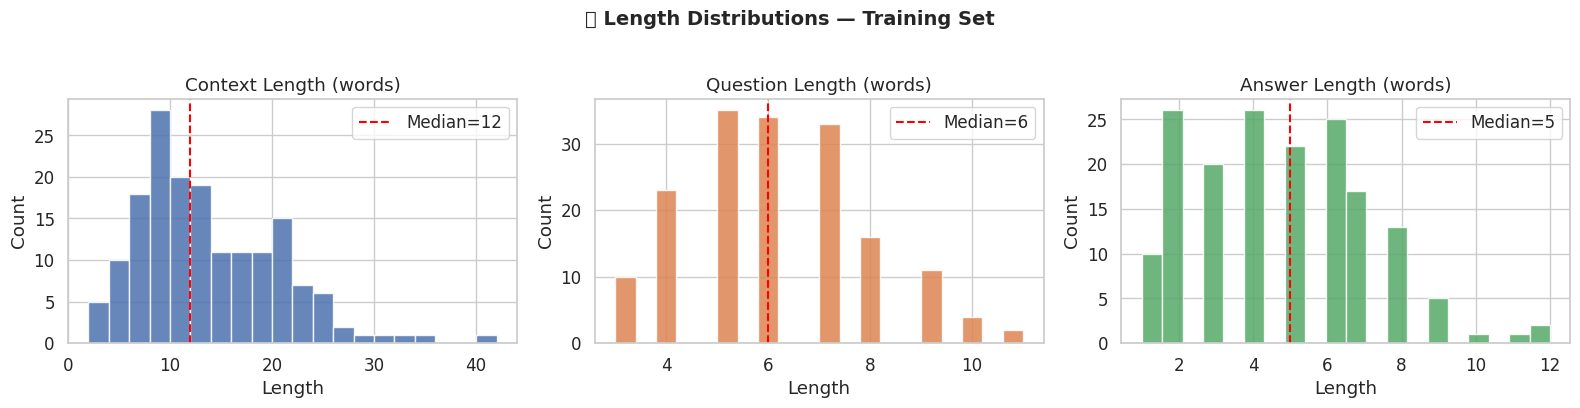

✅ Length distribution plot saved.


In [56]:
# ─── Distribution plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('📏 Length Distributions — Training Set', fontsize=14, fontweight='bold', y=1.02)

pairs = [
    ('ctx_word_len',  'Context Length (words)',   '#4C72B0'),
    ('q_word_len',    'Question Length (words)',  '#DD8452'),
    ('ans_word_len',  'Answer Length (words)',    '#55A868'),
]
for ax, (col, title, color) in zip(axes, pairs):
    ax.hist(train_df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(train_df[col].median(), color='red', linestyle='--', linewidth=1.5, label=f'Median={train_df[col].median():.0f}')
    ax.set_title(title)
    ax.set_xlabel('Length')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('length_distributions.png', bbox_inches='tight')
plt.show()
print('✅ Length distribution plot saved.')

/tmp/ipykernel_222/818732285.py:13: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_222/818732285.py:14: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  plt.savefig('topic_distribution.png', bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


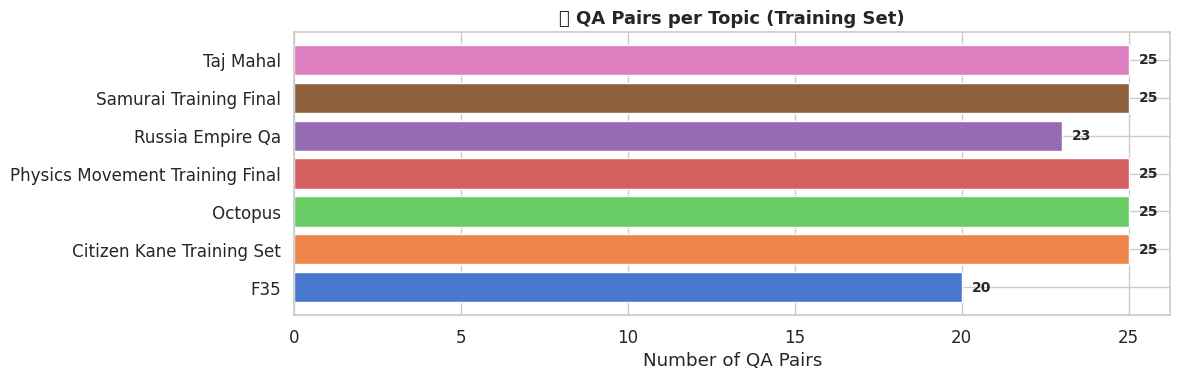

In [57]:
# ─── Per-topic QA count bar chart ─────────────────────────────────────────────
topic_counts = train_df.groupby('topic').size().reset_index(name='QA Pairs')
topic_counts['topic_clean'] = topic_counts['topic'].str.replace('_video','').str.replace('_',' ').str.title()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.barh(topic_counts['topic_clean'], topic_counts['QA Pairs'],
               color=sns.color_palette('muted', len(topic_counts)), edgecolor='white')
for bar, val in zip(bars, topic_counts['QA Pairs']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(val),
            va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Number of QA Pairs')
ax.set_title('📚 QA Pairs per Topic (Training Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('topic_distribution.png', bbox_inches='tight')
plt.show()

In [58]:
# ─── Language mixing analysis ─────────────────────────────────────────────────
def detect_language_mix(text: str) -> Dict[str, float]:
    """Return % Arabic chars, % Latin chars, and % digits in text."""
    chars = [c for c in text if not c.isspace()]
    total = max(len(chars), 1)
    arabic = sum(1 for c in chars if '\u0600' <= c <= '\u06FF')
    latin  = sum(1 for c in chars if c.isascii() and c.isalpha())
    digits = sum(1 for c in chars if c.isdigit())
    return {'arabic_pct': arabic/total*100, 'latin_pct': latin/total*100, 'digit_pct': digits/total*100}

lang_stats = train_df['context'].apply(detect_language_mix).apply(pd.Series)
print('─── Language Mix in Contexts ─────────────────────────────────────────────')
display(lang_stats.describe().round(2).style
    .set_caption('Language Mix Statistics (%)')
    .background_gradient(cmap='Greens', axis=0)
)

─── Language Mix in Contexts ─────────────────────────────────────────────


,arabic_pct,latin_pct,digit_pct
count,168.000000,168.000000,168.000000
mean,94.300000,1.590000,0.810000
std,6.940000,6.090000,2.370000
min,42.860000,0.000000,0.000000
25%,93.820000,0.000000,0.000000
50%,97.220000,0.000000,0.000000
75%,97.830000,0.000000,0.000000
max,99.030000,53.570000,13.790000


/tmp/ipykernel_222/30087934.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(type_counts.index, rotation=20, ha='right')
/tmp/ipykernel_222/30087934.py:32: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_222/30087934.py:33: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.savefig('answer_types.png', bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


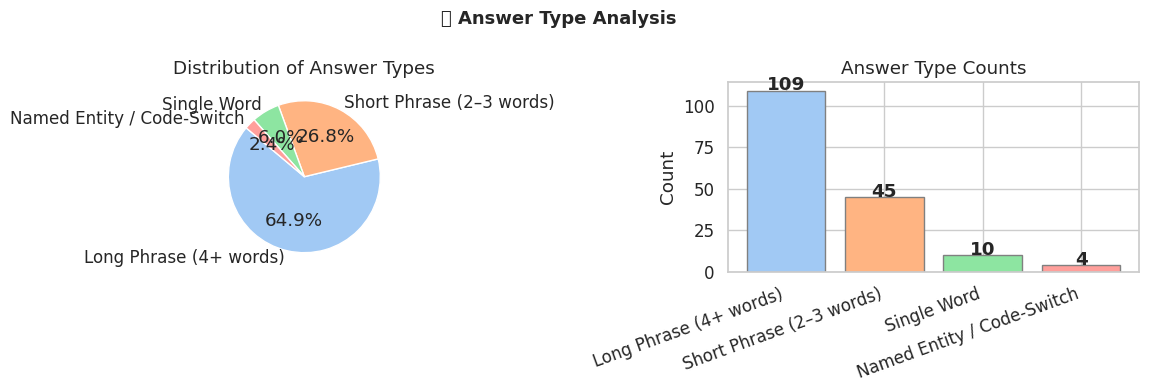

In [59]:
# ─── Answer type analysis (single word vs multi-word vs named entity) ─────────
def classify_answer(ans: str) -> str:
    if len(ans.split()) == 1:
        return 'Single Word'
    elif any(c.isascii() and c.isupper() for c in ans):
        return 'Named Entity / Code-Switch'
    elif len(ans.split()) <= 3:
        return 'Short Phrase (2–3 words)'
    else:
        return 'Long Phrase (4+ words)'

train_df['answer_type'] = train_df['answer'].apply(classify_answer)
type_counts = train_df['answer_type'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('🏷️ Answer Type Analysis', fontsize=13, fontweight='bold')

# Pie
ax1.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=140)
ax1.set_title('Distribution of Answer Types')

# Bar
ax2.bar(type_counts.index, type_counts.values,
        color=sns.color_palette('pastel'), edgecolor='grey')
ax2.set_xticklabels(type_counts.index, rotation=20, ha='right')
ax2.set_ylabel('Count')
ax2.set_title('Answer Type Counts')
for i, v in enumerate(type_counts.values):
    ax2.text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('answer_types.png', bbox_inches='tight')
plt.show()

---
## 4. 🧹 Text Preprocessing

### Preprocessing Pipeline Design

```
Raw Text
   │
   ├─► [1] Unicode Normalization     (fix encoding artefacts)
   ├─► [2] Alef Normalization        (أ إ آ ا → ا)
   ├─► [3] Alef Maksura / Teh Marbuta normalization
   ├─► [4] Diacritic (Tashkeel) Removal
   ├─► [5] Tatweel Removal           (مـــد → مد)
   ├─► [6] Punctuation Normalisation (keep Arabic + sentence delimiters)
   ├─► [7] Whitespace Collapse
   └─► Cleaned Text
```

In [60]:
# ─── Preprocessing functions ──────────────────────────────────────────────────

def step_unicode_normalize(text: str) -> str:
    """Step 1: Unicode NFC normalisation + cameltools unicode fix."""
    text = unicodedata.normalize('NFC', text)
    return normalize_unicode(text)

def step_normalize_alef(text: str) -> str:
    """Step 2: Normalize all Alef variants to bare Alef (ا)."""
    return normalize_alef_ar(text)

def step_normalize_endings(text: str) -> str:
    """Step 3: Normalize Alef Maksura (ى→ي) and Teh Marbuta (ة→ه)."""
    text = normalize_alef_maksura_ar(text)
    text = normalize_teh_marbuta_ar(text)
    return text

def step_remove_diacritics(text: str) -> str:
    """Step 4: Remove tashkeel (diacritics/harakat)."""
    return dediac_ar(text)

def step_remove_tatweel(text: str) -> str:
    """Step 5: Remove Arabic Tatweel (elongation character ـ)."""
    return araby.strip_tatweel(text)

def step_normalize_punctuation(text: str) -> str:
    """Step 6: Remove non-essential punctuation; keep Arabic sentence chars."""
    # Keep Arabic letters, digits, spaces, basic punctuation, Latin (for code-switch)
    text = re.sub(r'[\u200b-\u200f\u202a-\u202e\ufeff]', '', text)  # zero-width chars
    text = re.sub(r'[^\w\s\u0600-\u06FF.,!?؟،؛]', ' ', text)        # keep useful chars
    return text

def step_whitespace_collapse(text: str) -> str:
    """Step 7: Collapse multiple spaces to one; strip edges."""
    return re.sub(r'\s+', ' ', text).strip()


PIPELINE_STEPS = [
    ('Unicode Normalize',    step_unicode_normalize),
    ('Alef Normalize',       step_normalize_alef),
    ('Endings Normalize',    step_normalize_endings),
    ('Remove Diacritics',    step_remove_diacritics),
    ('Remove Tatweel',       step_remove_tatweel),
    ('Normalize Punctuation',step_normalize_punctuation),
    ('Whitespace Collapse',  step_whitespace_collapse),
]

def preprocess_text(text: str, steps=PIPELINE_STEPS) -> str:
    for _, fn in steps:
        text = fn(text)
    return text

print('✅ Preprocessing pipeline defined with', len(PIPELINE_STEPS), 'steps.')

✅ Preprocessing pipeline defined with 7 steps.


In [61]:
# ─── Show step-by-step transformation on a sample ─────────────────────────────
sample_text = train_df['context'].iloc[3]

print('━'*70)
print(f'  STEP 0 (RAW):  {sample_text[:120]}')
print('━'*70)

trace = sample_text
trace_rows = []
for i, (name, fn) in enumerate(PIPELINE_STEPS, 1):
    before = trace
    trace = fn(trace)
    changed = '✅ Changed' if before != trace else '⬜ Unchanged'
    trace_rows.append({'Step': f'{i}. {name}', 'Status': changed,
                       'Output (first 80 chars)': trace[:80]})

display(pd.DataFrame(trace_rows).style
    .set_caption('🔬 Step-by-Step Preprocessing Trace')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),('font-weight','bold')]}])
    .apply(lambda col: ['background-color: #d4f1c0' if '✅' in v else '' for v in col],
           subset=['Status'])
)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 0 (RAW):  في تلك الفترة، اعتمدت أفلام هوليوود على قوالب تقليدية مثل الويسترن والرومانسية. كانت القصص تنتهي بنهايات سعيدة متوقعة. ه
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Step,Status,Output (first 80 chars)
0,1. Unicode Normalize,⬜ Unchanged,في تلك الفترة، اعتمدت أفلام هوليوود على قوالب تقليدية مثل الويسترن والرومانسية.
1,2. Alef Normalize,✅ Changed,في تلك الفترة، اعتمدت افلام هوليوود على قوالب تقليدية مثل الويسترن والرومانسية.
2,3. Endings Normalize,✅ Changed,في تلك الفتره، اعتمدت افلام هوليوود علي قوالب تقليديه مثل الويسترن والرومانسيه.
3,4. Remove Diacritics,⬜ Unchanged,في تلك الفتره، اعتمدت افلام هوليوود علي قوالب تقليديه مثل الويسترن والرومانسيه.
4,5. Remove Tatweel,⬜ Unchanged,في تلك الفتره، اعتمدت افلام هوليوود علي قوالب تقليديه مثل الويسترن والرومانسيه.
5,6. Normalize Punctuation,⬜ Unchanged,في تلك الفتره، اعتمدت افلام هوليوود علي قوالب تقليديه مثل الويسترن والرومانسيه.
6,7. Whitespace Collapse,⬜ Unchanged,في تلك الفتره، اعتمدت افلام هوليوود علي قوالب تقليديه مثل الويسترن والرومانسيه.


In [62]:
# ─── Apply preprocessing to all splits ───────────────────────────────────────
for col in ['context', 'question', 'answer']:
    train_df[f'{col}_clean'] = train_df[col].apply(preprocess_text)
    test_df[f'{col}_clean']  = test_df[col].apply(preprocess_text)

# ─── Before / After length comparison ────────────────────────────────────────
train_df['ctx_len_before'] = train_df['context'].str.len()
train_df['ctx_len_after']  = train_df['context_clean'].str.len()
train_df['ctx_reduction']  = (1 - train_df['ctx_len_after'] / train_df['ctx_len_before']) * 100

comparison = pd.DataFrame({
    'Metric'    : ['Avg context chars (before)', 'Avg context chars (after)', 'Avg reduction (%)'],
    'Value'     : [train_df['ctx_len_before'].mean().round(1),
                   train_df['ctx_len_after'].mean().round(1),
                   train_df['ctx_reduction'].mean().round(2)],
})
display(comparison.style.set_caption('📉 Preprocessing Impact on Context Length')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),('font-weight','bold')]}])
)
print('✅ Preprocessing applied to all splits.')

,Metric,Value
0,Avg context chars (before),77.600000
1,Avg context chars (after),77.100000
2,Avg reduction (%),0.540000


✅ Preprocessing applied to all splits.


/tmp/ipykernel_222/3987629333.py:16: UserWarning: Glyph 129529 (\N{BROOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_222/3987629333.py:17: UserWarning: Glyph 129529 (\N{BROOM}) missing from font(s) DejaVu Sans.
  plt.savefig('preprocessing_impact.png', bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129529 (\N{BROOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


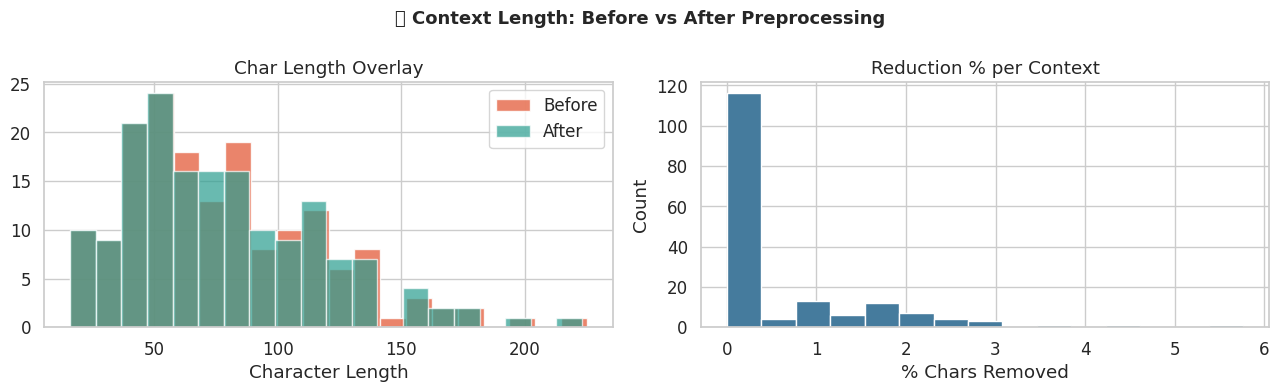

In [63]:
# ─── Before / After visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('🧹 Context Length: Before vs After Preprocessing', fontsize=13, fontweight='bold')

axes[0].hist(train_df['ctx_len_before'], bins=20, color='#E76F51', edgecolor='white', alpha=0.85, label='Before')
axes[0].hist(train_df['ctx_len_after'],  bins=20, color='#2A9D8F', edgecolor='white', alpha=0.70, label='After')
axes[0].set_title('Char Length Overlay')
axes[0].set_xlabel('Character Length')
axes[0].legend()

axes[1].hist(train_df['ctx_reduction'], bins=15, color='#457B9D', edgecolor='white')
axes[1].set_title('Reduction % per Context')
axes[1].set_xlabel('% Chars Removed')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('preprocessing_impact.png', bbox_inches='tight')
plt.show()

---
## 5. ✂️ Tokenization

We implement **three** tokenization strategies and compare them:

| Strategy | Description | Use Case |
|----------|-------------|----------|
| **Word-level** | Split on whitespace | Baseline; large vocab |
| **Character-level** | Split to individual chars | Handles OOV; small unit |
| **Subword (BPE-like)** | Split by character ngrams | Balance between word/char |

In [64]:
# ─── Tokenizer implementations ────────────────────────────────────────────────

class WordTokenizer:
    """Whitespace-based word tokenizer."""
    def tokenize(self, text: str) -> List[str]:
        return text.split()
    def __repr__(self): return 'WordTokenizer'


class CharTokenizer:
    """Character-level tokenizer."""
    def tokenize(self, text: str) -> List[str]:
        return list(text.replace(' ', '▁'))  # use ▁ to mark spaces
    def __repr__(self): return 'CharTokenizer'


class SubwordTokenizer:
    """Simple BPE-inspired subword tokenizer using character n-grams (no pretrained merges).
    Splits words greedily: tries length-4, then 3, then 2, then single chars."""
    def __init__(self, min_freq: int = 2, max_ngram: int = 4):
        self.min_freq = min_freq
        self.max_ngram = max_ngram
        self.vocab: set = set()

    def fit(self, texts: List[str]) -> 'SubwordTokenizer':
        freq = Counter()
        for t in texts:
            for w in t.split():
                for n in range(2, self.max_ngram + 1):
                    for i in range(len(w) - n + 1):
                        freq[w[i:i+n]] += 1
        self.vocab = {k for k, v in freq.items() if v >= self.min_freq}
        return self

    def tokenize(self, text: str) -> List[str]:
        tokens = []
        for word in text.split():
            i = 0
            while i < len(word):
                matched = False
                for n in range(min(self.max_ngram, len(word) - i), 0, -1):
                    sub = word[i:i+n]
                    if sub in self.vocab or n == 1:
                        tokens.append(sub)
                        i += n
                        matched = True
                        break
                if not matched:
                    tokens.append(word[i]); i += 1
        return tokens
    def __repr__(self): return 'SubwordTokenizer'


# ─── Initialise & fit ─────────────────────────────────────────────────────────
all_train_texts = (train_df['context_clean'].tolist() +
                   train_df['question_clean'].tolist())

word_tok    = WordTokenizer()
char_tok    = CharTokenizer()
subword_tok = SubwordTokenizer(min_freq=3, max_ngram=4).fit(all_train_texts)

print(f'Subword vocab size: {len(subword_tok.vocab):,}')
print('✅ All tokenizers initialised.')

Subword vocab size: 2,114
✅ All tokenizers initialised.


In [65]:
# ─── Visual comparison on a sample sentence ──────────────────────────────────
sample_sent = train_df['context_clean'].iloc[0]
short_sent  = ' '.join(sample_sent.split()[:8])

comp_rows = []
for tok in [word_tok, char_tok, subword_tok]:
    tokens = tok.tokenize(short_sent)
    comp_rows.append({
        'Tokenizer'  : repr(tok),
        'Token Count': len(tokens),
        'Tokens'     : '  |  '.join(tokens[:20]) + ('  …' if len(tokens) > 20 else ''),
    })

display(pd.DataFrame(comp_rows).style
    .set_caption(f'✂️ Tokenization Comparison — "{short_sent[:50]}…"')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),('font-weight','bold')]}])
    .set_properties(**{'text-align': 'right', 'direction': 'rtl'}, subset=['Tokens'])
)

,Tokenizer,Token Count,Tokens
0,WordTokenizer,8,في | ليله | 30 | اكتوبر | 1938، | انقطع | بث | اذاعي
1,CharTokenizer,38,ف | ي | ▁ | ل | ي | ل | ه | ▁ | 3 | 0 | ▁ | ا | ك | ت | و | ب | ر | ▁ | 1 | 9 …
2,SubwordTokenizer,18,في | ليله | 3 | 0 | اكت | وب | ر | 1 | 9 | 3 | 8 | ، | ان | قطع | ب | ث | اذاع | ي


/tmp/ipykernel_222/4069774628.py:25: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_222/4069774628.py:26: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.savefig('tokenizer_comparison.png', bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


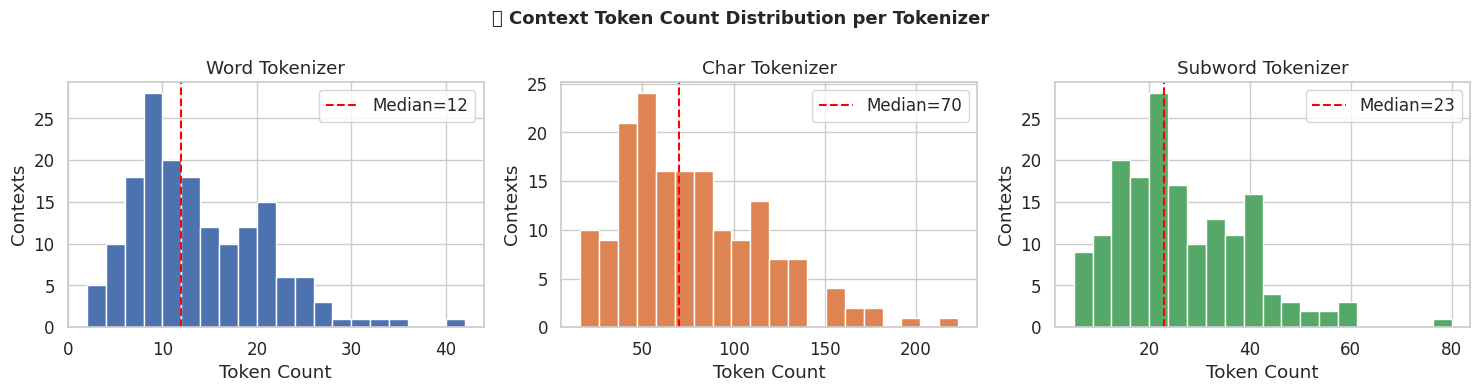

,Word,Char,Subword
count,168.000000,168.000000,168.000000
mean,13.300000,77.100000,26.200000
std,7.000000,39.100000,12.800000
min,2.000000,16.000000,5.000000
25%,8.000000,48.800000,17.000000
50%,12.000000,70.000000,23.000000
75%,18.000000,100.800000,34.200000
max,42.000000,223.000000,80.000000


In [66]:
# ─── Token count distribution across strategies ───────────────────────────────
strats = [
    ('Word', word_tok),
    ('Char', char_tok),
    ('Subword', subword_tok),
]

tok_counts = {}
for name, tok in strats:
    tok_counts[name] = train_df['context_clean'].apply(lambda t: len(tok.tokenize(t)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('🔢 Context Token Count Distribution per Tokenizer', fontsize=13, fontweight='bold')

colors = ['#4C72B0', '#DD8452', '#55A868']
for ax, (name, counts), color in zip(axes, tok_counts.items(), colors):
    ax.hist(counts, bins=20, color=color, edgecolor='white')
    ax.axvline(counts.median(), color='red', linestyle='--', linewidth=1.5,
               label=f'Median={counts.median():.0f}')
    ax.set_title(f'{name} Tokenizer')
    ax.set_xlabel('Token Count')
    ax.set_ylabel('Contexts')
    ax.legend()

plt.tight_layout()
plt.savefig('tokenizer_comparison.png', bbox_inches='tight')
plt.show()

# ─── Summary stats table ──────────────────────────────────────────────────────
tok_stats = pd.DataFrame({n: c.describe() for n, c in tok_counts.items()}).round(1)
display(tok_stats.style
    .set_caption('📊 Token Count Statistics per Strategy')
    .background_gradient(cmap='YlOrBr', axis=None)
)

---
## 6. 🎯 Answer Span Extraction

For extractive QA, the model predicts **start and end token indices** of the answer within the context tokens. Here we locate those positions.

In [67]:
def find_answer_span(context_tokens: List[str], answer_tokens: List[str]) -> Tuple[int, int]:
    """
    Exact token-sequence search.
    Returns (start_idx, end_idx) inclusive, or (-1, -1) if not found.
    """
    n, m = len(context_tokens), len(answer_tokens)
    if m == 0 or n == 0 or m > n:
        return -1, -1

    for i in range(n - m + 1):
        if context_tokens[i:i + m] == answer_tokens:
            return i, i + m - 1
    return -1, -1


def aligned_word_tokens_from_raw(raw_text: str, preprocess_fn=preprocess_text) -> List[Dict]:
    """
    Tokenize raw text by whitespace, preprocess each raw token, and keep its raw char span.
    This preserves a usable mapping from cleaned word tokens back to raw offsets.
    """
    raw_text = '' if pd.isna(raw_text) else str(raw_text)
    aligned = []

    for m in re.finditer(r'\S+', raw_text):
        raw_piece = m.group(0)
        clean_piece = preprocess_fn(raw_piece)
        clean_tokens = [tok for tok in clean_piece.split() if tok]

        for tok in clean_tokens:
            aligned.append({
                'token': tok,
                'raw_start': m.start(),
                'raw_end': m.end(),
            })

    return aligned


def char_span_to_token_span(raw_context: str, answer_text: str, answer_start: int) -> Tuple[int, int, List[str]]:
    """
    Convert raw character span -> token span in cleaned context tokens.
    Returns (start_idx, end_idx, cleaned_context_tokens).
    """
    raw_context = '' if pd.isna(raw_context) else str(raw_context)
    answer_text = '' if pd.isna(answer_text) else str(answer_text)

    if pd.isna(answer_start):
        return -1, -1, []

    answer_start = int(answer_start)
    if answer_start < 0:
        return -1, -1, []

    answer_end = answer_start + len(answer_text)

    aligned = aligned_word_tokens_from_raw(raw_context, preprocess_fn=preprocess_text)
    ctx_tokens = [x['token'] for x in aligned]
    ans_tokens = [tok for tok in preprocess_text(answer_text).split() if tok]

    if not ctx_tokens or not ans_tokens:
        return -1, -1, ctx_tokens

    # First try: tokens whose raw spans overlap the raw answer span
    overlapping = [
        i for i, x in enumerate(aligned)
        if not (x['raw_end'] <= answer_start or x['raw_start'] >= answer_end)
    ]

    if overlapping:
        s0, e0 = overlapping[0], overlapping[-1]

        if ctx_tokens[s0:e0 + 1] == ans_tokens:
            return s0, e0, ctx_tokens

        # Local fallback around the overlap zone
        left = max(0, s0 - 8)
        right = min(len(ctx_tokens), e0 + 9)
        local_s, local_e = find_answer_span(ctx_tokens[left:right], ans_tokens)
        if local_s != -1:
            return left + local_s, left + local_e, ctx_tokens

    # Final fallback: full exact search on cleaned context tokens
    s, e = find_answer_span(ctx_tokens, ans_tokens)
    return s, e, ctx_tokens


def build_span_aligned_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rebuild clean columns and span indices using raw answer offsets.
    """
    rows = []

    for _, row in df.iterrows():
        s, e, ctx_tokens = char_span_to_token_span(
            raw_context=row['context'],
            answer_text=row['answer'],
            answer_start=row['answer_start'],
        )

        answer_clean = ' '.join(preprocess_text(str(row['answer'])).split())
        question_clean = ' '.join(preprocess_text(str(row['question'])).split())
        context_clean = ' '.join(ctx_tokens)

        decoded_span = ' '.join(ctx_tokens[s:e + 1]) if s != -1 and e != -1 else ''
        span_match = int(decoded_span == answer_clean)

        new_row = row.to_dict()
        new_row.update({
            'question_clean': question_clean,
            'context_clean': context_clean,
            'answer_clean': answer_clean,
            'start_idx': s,
            'end_idx': e,
            'decoded_span_clean': decoded_span,
            'span_match': span_match,
        })
        rows.append(new_row)

    return pd.DataFrame(rows)


# ─── Build corrected span-aligned dataframes ──────────────────────────────────
train_df = build_span_aligned_df(train_df)
test_df  = build_span_aligned_df(test_df)

# ─── Diagnostics ──────────────────────────────────────────────────────────────
train_found = (train_df['start_idx'] != -1).sum()
test_found  = (test_df['start_idx']  != -1).sum()

span_stats = pd.DataFrame([
    {
        'Split': 'Train',
        'Total': len(train_df),
        'Spans Found': train_found,
        'Exact Clean Match': int(train_df['span_match'].sum()),
        'Success Rate (%)': round(train_found / len(train_df) * 100, 1),
        'Exact Match Rate (%)': round(train_df['span_match'].mean() * 100, 1),
    },
    {
        'Split': 'Test',
        'Total': len(test_df),
        'Spans Found': test_found,
        'Exact Clean Match': int(test_df['span_match'].sum()),
        'Success Rate (%)': round(test_found / len(test_df) * 100, 1),
        'Exact Match Rate (%)': round(test_df['span_match'].mean() * 100, 1),
    },
])

display(span_stats.style
    .set_caption('🎯 Offset-Based Answer Span Extraction Diagnostics')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),('font-weight','bold')]}])
    .background_gradient(cmap='Greens', subset=['Success Rate (%)', 'Exact Match Rate (%)'])
)


,Split,Total,Spans Found,Exact Clean Match,Success Rate (%),Exact Match Rate (%)
0,Train,168,22,22,13.100000,13.100000
1,Test,72,7,7,9.700000,9.700000


/tmp/ipykernel_222/1535753375.py:24: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_222/1535753375.py:25: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.savefig('span_analysis.png', bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


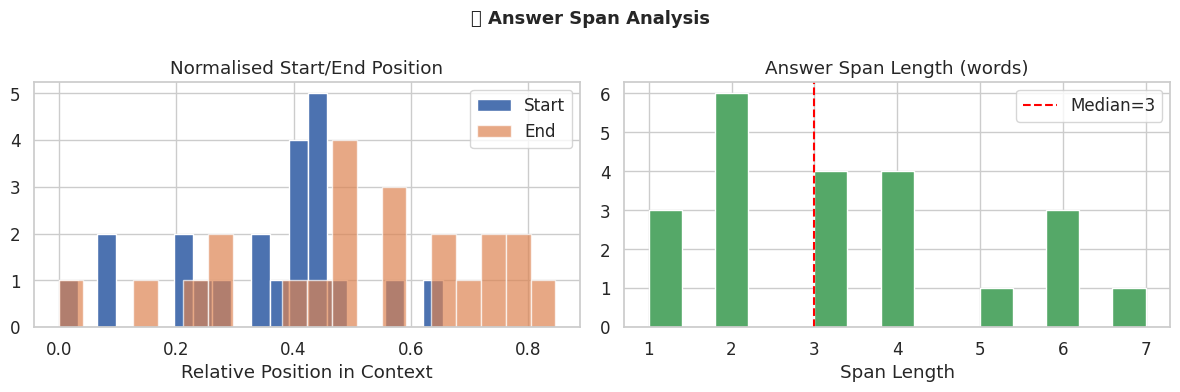

In [68]:
# ─── Visualise span positions in contexts ─────────────────────────────────────
found = train_df[train_df['start_idx'] != -1].copy()
ctx_lens = found['context_clean'].apply(lambda t: len(word_tok.tokenize(t)))
rel_start = found['start_idx'] / ctx_lens  # normalised 0→1
rel_end   = found['end_idx']   / ctx_lens
span_len  = found['end_idx'] - found['start_idx'] + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('📍 Answer Span Analysis', fontsize=13, fontweight='bold')

axes[0].hist(rel_start, bins=20, color='#4C72B0', edgecolor='white', label='Start')
axes[0].hist(rel_end,   bins=20, color='#DD8452', edgecolor='white', alpha=0.7, label='End')
axes[0].set_title('Normalised Start/End Position')
axes[0].set_xlabel('Relative Position in Context')
axes[0].legend()

axes[1].hist(span_len, bins=15, color='#55A868', edgecolor='white')
axes[1].axvline(span_len.median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Median={span_len.median():.0f}')
axes[1].set_title('Answer Span Length (words)')
axes[1].set_xlabel('Span Length')
axes[1].legend()

plt.tight_layout()
plt.savefig('span_analysis.png', bbox_inches='tight')
plt.show()

---
## 7. 📖 Vocabulary Building

In [69]:
# ─── Special tokens ───────────────────────────────────────────────────────────
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
SEP_TOKEN = '<SEP>'   # separator between question and context
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN, SEP_TOKEN]


class Vocabulary:
    """Maps tokens ↔ integer indices. Supports min_freq filtering."""

    def __init__(self, min_freq: int = 1, special_tokens: List[str] = SPECIAL_TOKENS):
        self.min_freq = min_freq
        self.token2idx: Dict[str, int] = {}
        self.idx2token: Dict[int, str] = {}
        self.freq: Counter = Counter()
        # Insert specials first (fixed indices)
        for i, tok in enumerate(special_tokens):
            self.token2idx[tok] = i
            self.idx2token[i]   = tok
        self._next_idx = len(special_tokens)

    @property
    def pad_idx(self): return self.token2idx[PAD_TOKEN]
    @property
    def unk_idx(self): return self.token2idx[UNK_TOKEN]

    def build(self, token_lists: List[List[str]]) -> 'Vocabulary':
        for tl in token_lists:
            self.freq.update(tl)
        for token, cnt in self.freq.items():
            if cnt >= self.min_freq and token not in self.token2idx:
                self.token2idx[token] = self._next_idx
                self.idx2token[self._next_idx] = token
                self._next_idx += 1
        return self

    def encode(self, tokens: List[str]) -> List[int]:
        return [self.token2idx.get(t, self.unk_idx) for t in tokens]

    def decode(self, ids: List[int]) -> List[str]:
        return [self.idx2token.get(i, UNK_TOKEN) for i in ids]

    def __len__(self):  return len(self.token2idx)
    def __repr__(self): return f'Vocabulary(size={len(self)}, min_freq={self.min_freq})'


# ─── Build from training contexts + questions ─────────────────────────────────
vocab = Vocabulary(min_freq=1)
vocab.build(
    [word_tok.tokenize(t) for t in train_df['context_clean']] +
    [word_tok.tokenize(t) for t in train_df['question_clean']]
)
print(vocab)

Vocabulary(size=1381, min_freq=1)


In [70]:
# ─── Vocabulary statistics table ──────────────────────────────────────────────
all_freqs = list(vocab.freq.values())
singletons = sum(1 for v in all_freqs if v == 1)

vocab_stats = pd.DataFrame([
    {'Metric': 'Vocabulary Size (total)', 'Value': f'{len(vocab):,}'},
    {'Metric': 'Special Tokens',          'Value': str(len(SPECIAL_TOKENS))},
    {'Metric': 'Unique Content Tokens',   'Value': f'{len(vocab)-len(SPECIAL_TOKENS):,}'},
    {'Metric': 'Singleton Tokens (freq=1)','Value': f'{singletons:,}  ({singletons/len(vocab)*100:.1f}%)'},
    {'Metric': 'Most Frequent Token',     'Value': vocab.freq.most_common(1)[0][0] +
                                                   f" (freq={vocab.freq.most_common(1)[0][1]})"},
    {'Metric': 'Avg Token Frequency',     'Value': f'{np.mean(all_freqs):.2f}'},
])
display(vocab_stats.style
    .set_caption('📖 Vocabulary Statistics')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),('font-weight','bold')]}])
    .hide(axis='index')
)

Metric,Value
Vocabulary Size (total),"1,381"
Special Tokens,5
Unique Content Tokens,"1,376"
Singleton Tokens (freq=1),"1,041 (75.4%)"
Most Frequent Token,ما (freq=95)
Avg Token Frequency,1.74


/tmp/ipykernel_222/3563631604.py:21: UserWarning: Glyph 128214 (\N{OPEN BOOK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_222/3563631604.py:22: UserWarning: Glyph 128214 (\N{OPEN BOOK}) missing from font(s) DejaVu Sans.
  plt.savefig('vocab_analysis.png', bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128214 (\N{OPEN BOOK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


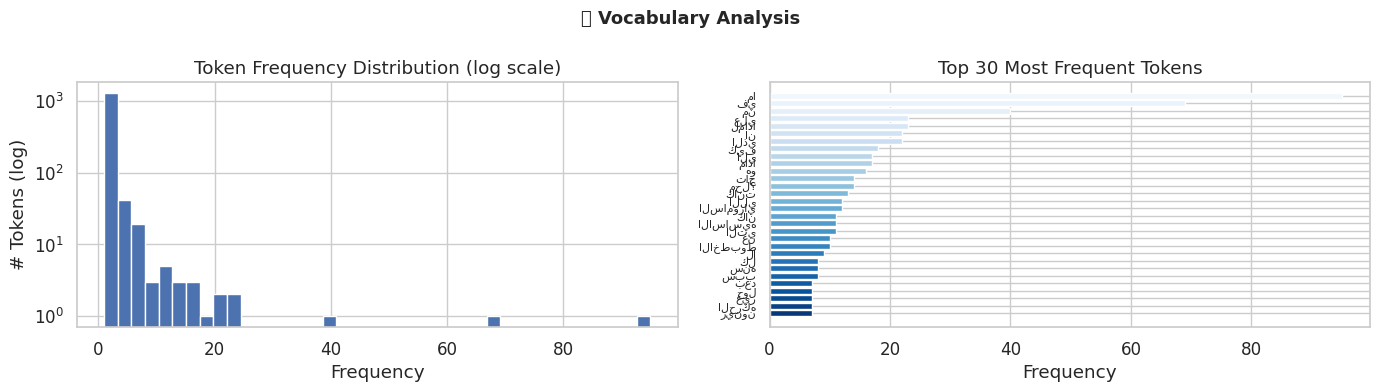

In [71]:
# ─── Frequency distribution & top-30 tokens ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('📖 Vocabulary Analysis', fontsize=13, fontweight='bold')

# Log-scale frequency histogram
axes[0].hist(all_freqs, bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Token Frequency Distribution (log scale)')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('# Tokens (log)')

# Top 30 most frequent tokens
top30 = vocab.freq.most_common(30)
top_tokens, top_freqs = zip(*top30)
axes[1].barh(range(30), top_freqs[::-1], color=sns.color_palette('Blues_r', 30))
axes[1].set_yticks(range(30))
axes[1].set_yticklabels(top_tokens[::-1], fontsize=8)
axes[1].set_title('Top 30 Most Frequent Tokens')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('vocab_analysis.png', bbox_inches='tight')
plt.show()

In [72]:
# ─── OOV analysis on test set ─────────────────────────────────────────────────
test_tokens_ctx  = [t for row in test_df['context_clean']  for t in word_tok.tokenize(row)]
test_tokens_q    = [t for row in test_df['question_clean'] for t in word_tok.tokenize(row)]
test_all_tokens  = test_tokens_ctx + test_tokens_q

oov_tokens = [t for t in test_all_tokens if t not in vocab.token2idx]
oov_rate   = len(oov_tokens) / max(len(test_all_tokens), 1) * 100

print(f'Test set total tokens : {len(test_all_tokens):>6,}')
print(f'OOV tokens            : {len(oov_tokens):>6,}')
print(f'OOV rate              : {oov_rate:>6.2f}%')

if oov_tokens:
    oov_cnt = Counter(oov_tokens).most_common(15)
    oov_df  = pd.DataFrame(oov_cnt, columns=['OOV Token', 'Count'])
    display(oov_df.style
        .set_caption(f'⚠️ Top OOV Tokens in Test Set (rate={oov_rate:.1f}%)')
        .set_table_styles([{'selector':'caption','props':[('font-size','13px'),('font-weight','bold')]}])
        .bar(subset=['Count'], color='#f4a261')
    )

Test set total tokens :  1,183
OOV tokens            :    321
OOV rate              :  27.13%


,OOV Token,Count
0,تفسير,3
1,قائما,2
2,معينه.,2
3,فقط،,2
4,البيئات,2
5,وقت,2
6,الاستجابه,2
7,يقبل,2
8,الاستمرار,2
9,مفارقات,2


---
## 8. 🗂️ Data Splitting, Padding & Batch Construction

In [73]:
import random
random.seed(42)

def keep_only_valid_rows(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    before = len(df)

    basic_mask = (
        df['start_idx'].ge(0) &
        df['end_idx'].ge(df['start_idx'])
    )

    cleaned = df.loc[basic_mask].reset_index(drop=True).copy()

    print(f"{split_name}: kept {len(cleaned)}/{before} rows "
          f"({len(cleaned)/before*100:.1f}%) with valid span indices")

    if "span_match" in cleaned.columns:
        exact = int(cleaned["span_match"].sum())
        print(f"{split_name}: exact clean matches inside kept rows = "
              f"{exact}/{len(cleaned)} ({100*exact/max(len(cleaned),1):.1f}%)")

    return cleaned


train_df = keep_only_valid_rows(train_df, 'Train')
test_df  = keep_only_valid_rows(test_df,  'Test')

# train/validation split happens ONLY after span validation
indices = list(range(len(train_df)))
random.shuffle(indices)

val_size  = int(0.15 * len(indices))
val_idx   = indices[:val_size]
train_idx = indices[val_size:]

df_train = train_df.iloc[train_idx].reset_index(drop=True)
df_val   = train_df.iloc[val_idx].reset_index(drop=True)
df_test  = test_df.reset_index(drop=True)

split_summary = pd.DataFrame([
    {'Split': 'Train',      'Samples': len(df_train), '%': f'{len(df_train)/len(train_df)*100:.1f}%'},
    {'Split': 'Validation', 'Samples': len(df_val),   '%': f'{len(df_val)/len(train_df)*100:.1f}%'},
    {'Split': 'Test',       'Samples': len(df_test),  '%': 'held-out'},
])

display(split_summary.style
    .set_caption('🗂️ Corrected Data Split Summary')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),('font-weight','bold')]}])
    .hide(axis='index')
    .background_gradient(cmap='Blues', subset=['Samples'])
)

Train: kept 22/168 rows (13.1%) with valid span indices
Train: exact clean matches inside kept rows = 22/22 (100.0%)
Test: kept 7/72 rows (9.7%) with valid span indices
Test: exact clean matches inside kept rows = 7/7 (100.0%)


Split,Samples,%
Train,19,86.4%
Validation,3,13.6%
Test,7,held-out


In [74]:
# ─── Encoding & padding utilities ────────────────────────────────────────────

def encode_and_pad(tokens: List[str], vocab: Vocabulary,
                   max_len: int, add_sos_eos: bool = False) -> List[int]:
    """Encode tokens → ids; add SOS/EOS if requested; pad to max_len or truncate."""
    ids = vocab.encode(tokens)
    if add_sos_eos:
        ids = [vocab.token2idx[SOS_TOKEN]] + ids + [vocab.token2idx[EOS_TOKEN]]
    if len(ids) > max_len:
        ids = ids[:max_len]
    pad_ids = ids + [vocab.pad_idx] * (max_len - len(ids))
    return pad_ids


def encode_input(row: pd.Series,
                 vocab     : Vocabulary,
                 tokenizer,
                 max_ctx   : int = 100,
                 max_q     : int = 30) -> Dict:
    """
    Encodes one (question, context, answer) triplet to integer tensors.
    Concatenates question + [SEP] + context into a single sequence.
    Returns dict with: input_ids, attention_mask, start_idx, end_idx.
    """
    q_toks   = tokenizer.tokenize(row['question_clean'])[:max_q]
    ctx_toks = tokenizer.tokenize(row['context_clean'])[:max_ctx]
    sep      = [SEP_TOKEN]
    combined = q_toks + sep + ctx_toks
    max_combined = max_q + 1 + max_ctx

    input_ids      = encode_and_pad(combined, vocab, max_combined)
    attention_mask = [1 if i != vocab.pad_idx else 0 for i in input_ids]

    # Adjust span indices to account for [question + SEP] offset
    q_offset = len(q_toks) + 1  # +1 for SEP
    start = row['start_idx'] + q_offset if row['start_idx'] != -1 else -1
    end   = row['end_idx']   + q_offset if row['end_idx']   != -1 else -1

    # Clamp to max_combined
    start = min(start, max_combined - 1) if start != -1 else -1
    end   = min(end,   max_combined - 1) if end   != -1 else -1

    return {'input_ids': input_ids, 'attention_mask': attention_mask,
            'start_idx': start, 'end_idx': end}


# ─── Test on a single sample ──────────────────────────────────────────────────
sample_enc = encode_input(df_train.iloc[0], vocab, word_tok)

encoding_diag = pd.DataFrame([
    {'Field': 'input_ids length',  'Value': len(sample_enc['input_ids'])},
    {'Field': 'Non-PAD tokens',    'Value': sum(sample_enc['attention_mask'])},
    {'Field': 'start_idx',         'Value': sample_enc['start_idx']},
    {'Field': 'end_idx',           'Value': sample_enc['end_idx']},
    {'Field': 'Answer span tokens','Value': sample_enc['end_idx'] - sample_enc['start_idx'] + 1
                                            if sample_enc['start_idx'] != -1 else 'N/A'},
])
display(encoding_diag.style
    .set_caption('🔢 Sample Encoding Diagnostics')
    .hide(axis='index')
)
print('First 20 input_ids:', sample_enc['input_ids'][:20])

Field,Value
input_ids length,131
Non-PAD tokens,24
start_idx,13
end_idx,14
Answer span tokens,2


First 20 input_ids: [226, 1046, 1332, 907, 908, 996, 1333, 1330, 921, 1334, 1335, 4, 919, 920, 921, 922, 923, 404, 924, 925]


Array,Shape,Dtype,Sample (first item)
input_ids,"(8, 131)",int64,"[226, 1213, 58, 419, 1214, 94, 1215, 4, 94, 298]"
attention_mask,"(8, 131)",int64,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
start_indices,"(8,)",int64,[18]
end_indices,"(8,)",int64,[21]


/tmp/ipykernel_222/2379369376.py:50: UserWarning: Glyph 128450 (\N{CARD INDEX DIVIDERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_222/2379369376.py:51: UserWarning: Glyph 128450 (\N{CARD INDEX DIVIDERS}) missing from font(s) DejaVu Sans.
  plt.savefig('padding_heatmap.png', bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128450 (\N{CARD INDEX DIVIDERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


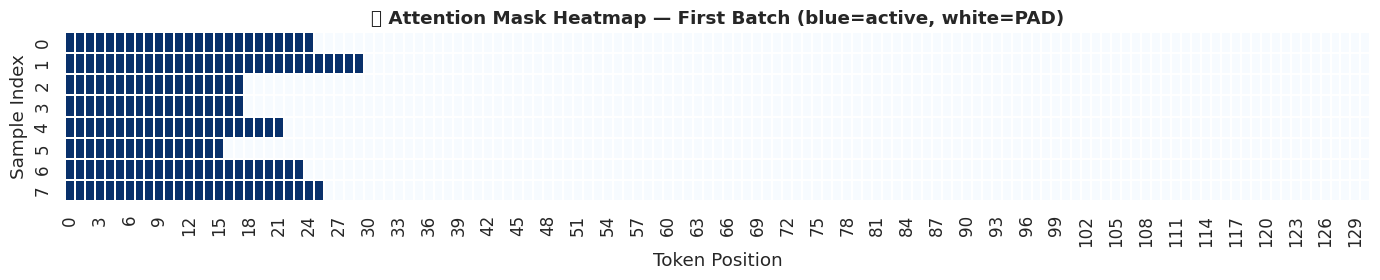

In [75]:
# ─── Batch builder ────────────────────────────────────────────────────────────

def build_batch(
    df       : pd.DataFrame,
    vocab    : Vocabulary,
    tokenizer,
    batch_size: int = 8,
    max_ctx  : int = 100,
    max_q    : int = 30,
    shuffle  : bool = True,
):
    """Generator that yields (input_ids, attention_masks, starts, ends) NumPy arrays."""
    rows = df.to_dict('records')
    if shuffle:
        random.shuffle(rows)
    for i in range(0, len(rows), batch_size):
        chunk = rows[i: i + batch_size]
        encoded = [encode_input(pd.Series(r), vocab, tokenizer, max_ctx, max_q) for r in chunk]
        yield (
            np.array([e['input_ids']       for e in encoded]),
            np.array([e['attention_mask']  for e in encoded]),
            np.array([e['start_idx']       for e in encoded]),
            np.array([e['end_idx']         for e in encoded]),
        )


# ─── Inspect one batch ────────────────────────────────────────────────────────
batch_gen = build_batch(df_train, vocab, word_tok, batch_size=8)
inp, mask, starts, ends = next(batch_gen)

batch_diag = pd.DataFrame({
    'Array'  : ['input_ids', 'attention_mask', 'start_indices', 'end_indices'],
    'Shape'  : [inp.shape, mask.shape, starts.shape, ends.shape],
    'Dtype'  : [inp.dtype, mask.dtype, starts.dtype, ends.dtype],
    'Sample (first item)': [inp[0,:10].tolist(), mask[0,:10].tolist(),
                             [starts[0]], [ends[0]]],
})
display(batch_diag.style
    .set_caption('📦 Batch Structure — First Batch from Train Set')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),('font-weight','bold')]}])
    .hide(axis='index')
)

# ─── Padding efficiency heatmap (first 8 samples) ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(mask, ax=ax, cmap='Blues', cbar=False, linewidths=0.3, linecolor='white')
ax.set_title('🗂️ Attention Mask Heatmap — First Batch (blue=active, white=PAD)', fontweight='bold')
ax.set_xlabel('Token Position')
ax.set_ylabel('Sample Index')
plt.tight_layout()
plt.savefig('padding_heatmap.png', bbox_inches='tight')
plt.show()

---
## 9. 🚀 Inference Pipeline

The inference pipeline converts **raw (question, context) text → predicted answer string**.  
It is model-agnostic: the `model_fn` argument accepts any callable that returns `(start_logits, end_logits)`.

In [76]:
# ─── Inference pipeline ──────────────────────────────────────────────────────

class QAPipeline:
    """
    End-to-end inference pipeline for Arabic Extractive QA.
    """

    def __init__(self, vocab: Vocabulary, tokenizer, model_fn=None,
                 max_ctx: int = 100, max_q: int = 30, max_answer_len: int = 25):
        self.vocab = vocab
        self.tokenizer = tokenizer
        self.model_fn = model_fn
        self.max_ctx = max_ctx
        self.max_q = max_q
        self.max_len = max_q + 1 + max_ctx
        self.max_answer_len = max_answer_len

    def _preprocess(self, text: str) -> str:
        return preprocess_text(text)

    def _encode(self, question: str, context: str):
        q_clean = self._preprocess(question)
        ctx_clean = self._preprocess(context)

        q_toks = self.tokenizer.tokenize(q_clean)[:self.max_q]
        ctx_toks = self.tokenizer.tokenize(ctx_clean)[:self.max_ctx]

        combined = q_toks + [SEP_TOKEN] + ctx_toks

        ids = encode_and_pad(combined, self.vocab, self.max_len)
        mask = [1 if i != self.vocab.pad_idx else 0 for i in ids]

        q_offset = len(q_toks) + 1
        active_ctx_len = len(ctx_toks)

        return ids, mask, q_offset, active_ctx_len, q_toks, ctx_toks, combined

    def _best_span(self, start_logits, end_logits, q_offset, active_ctx_len):
        start_logits = torch.tensor(start_logits).float()[0]
        end_logits = torch.tensor(end_logits).float()[0]
    
        ctx_start = q_offset
        ctx_end = q_offset + active_ctx_len - 1
    
        best_score = -1e9
        best_s = ctx_start
        best_e = ctx_start
    
        # main search
        for i in range(ctx_start, ctx_end + 1):
            max_j = min(i + self.max_answer_len - 1, ctx_end)
    
            for j in range(i, max_j + 1):
                length = j - i + 1
    
                # mild length penalty only for longer spans
                score = start_logits[i].item() + end_logits[j].item() - 0.02 * max(length - 8, 0)
    
                if score > best_score:
                    best_score = score
                    best_s = i
                    best_e = j
    
        # left-boundary rescue:
        # if an earlier start is nearly as good, prefer the longer phrase
        rescued_s = best_s
        best_start_logit = start_logits[best_s].item()
    
        for cand_s in range(max(ctx_start, best_s - 2), best_s):
            cand_logit = start_logits[cand_s].item()
    
            # allow a slightly weaker earlier start if it expands the phrase meaningfully
            if cand_logit >= best_start_logit - 1.0:
                rescued_s = cand_s
                break
    
        return rescued_s, best_e, float(best_score)

    def predict(self, question: str, context: str) -> Dict:
        ids, mask, q_offset, active_ctx_len, q_toks, ctx_toks, combined = self._encode(
            question, context
        )

        if active_ctx_len == 0:
            return {
                "question": question,
                "predicted": "",
                "start_token": -1,
                "end_token": -1,
                "confidence": 0.0,
                "question_tokens": q_toks,
                "context_tokens": ctx_toks,
            }

        if self.model_fn is not None:
            inp = np.array([ids])
            start_logits, end_logits = self.model_fn(inp)

            start_pos, end_pos, confidence = self._best_span(
                start_logits,
                end_logits,
                q_offset,
                active_ctx_len
            )
        else:
            start_pos = q_offset + random.randint(0, max(active_ctx_len - 1, 0))
            end_pos = min(start_pos + random.randint(0, 3), q_offset + active_ctx_len - 1)
            confidence = 0.0

        # Build answer from the original combined tokens, not vocab.decode()
        answer_tokens = combined[start_pos:end_pos + 1]
        answer_tokens = [tok for tok in answer_tokens if tok not in [PAD_TOKEN, SEP_TOKEN]]
        answer_str = " ".join(answer_tokens).strip()

        # Fallback debug path
        if not answer_str:
            answer_ids = ids[start_pos:end_pos + 1]
            decoded_tokens = self.vocab.decode(answer_ids)
            answer_str = " ".join(
                tok for tok in decoded_tokens if tok not in [PAD_TOKEN, SEP_TOKEN]
            ).strip()

        return {
            "question": question,
            "predicted": answer_str,
            "start_token": start_pos,
            "end_token": end_pos,
            "confidence": confidence,
            "question_tokens": q_toks,
            "context_tokens": ctx_toks,
        }


pipeline = QAPipeline(vocab=vocab, tokenizer=word_tok, model_fn=None)
print("✅ QAPipeline ready.")

✅ QAPipeline ready.


In [77]:
if len(df_test) == 0:
    raise ValueError("df_test is empty after filtering.")

demo_rows = df_test.sample(n=min(5, len(df_test)), random_state=7).reset_index(drop=True)

In [78]:
# ─── Pipeline step latency profiling ─────────────────────────────────────────
import time

test_q   = df_test['question'].iloc[0]
test_ctx = df_test['context'].iloc[0]

steps_timing = []

t0 = time.perf_counter()
q_clean   = preprocess_text(test_q)
ctx_clean = preprocess_text(test_ctx)
steps_timing.append({'Step': '1. Preprocess Text', 'Time (ms)': round((time.perf_counter()-t0)*1000, 3)})

t0 = time.perf_counter()
q_toks   = word_tok.tokenize(q_clean)
ctx_toks = word_tok.tokenize(ctx_clean)
steps_timing.append({'Step': '2. Tokenize', 'Time (ms)': round((time.perf_counter()-t0)*1000, 3)})

t0 = time.perf_counter()
combined = q_toks + [SEP_TOKEN] + ctx_toks
input_ids = encode_and_pad(combined, vocab, 131)
steps_timing.append({'Step': '3. Encode + Pad', 'Time (ms)': round((time.perf_counter()-t0)*1000, 3)})

t0 = time.perf_counter()
# (model forward pass — placeholder)
_ = np.random.rand(1, 131)  # mock logits
steps_timing.append({'Step': '4. Model Forward (mock)', 'Time (ms)': round((time.perf_counter()-t0)*1000, 3)})

t0 = time.perf_counter()
_ = ' '.join(vocab.decode(input_ids[10:13]))
steps_timing.append({'Step': '5. Decode Answer', 'Time (ms)': round((time.perf_counter()-t0)*1000, 3)})

timing_df = pd.DataFrame(steps_timing)
timing_df['% of Total'] = (timing_df['Time (ms)'] / timing_df['Time (ms)'].sum() * 100).round(1)
display(timing_df.style
    .set_caption('⏱️ Per-Step Inference Latency (single sample)')
    .set_table_styles([{'selector':'caption','props':[('font-size','13px'),('font-weight','bold')]}])
    .bar(subset=['Time (ms)'], color='#a8dadc')
    .hide(axis='index')
)

Step,Time (ms),% of Total
1. Preprocess Text,0.214000,32.700000
2. Tokenize,0.099000,15.100000
3. Encode + Pad,0.108000,16.500000
4. Model Forward (mock),0.156000,23.800000
5. Decode Answer,0.078000,11.900000


---
## 10. 📐 Pipeline Diagram

Complete data flow from raw text to model-ready tensors and back to answer string.

/tmp/ipykernel_222/4273552651.py:62: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_222/4273552651.py:63: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.savefig('pipeline_diagram.png', bbox_inches='tight', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


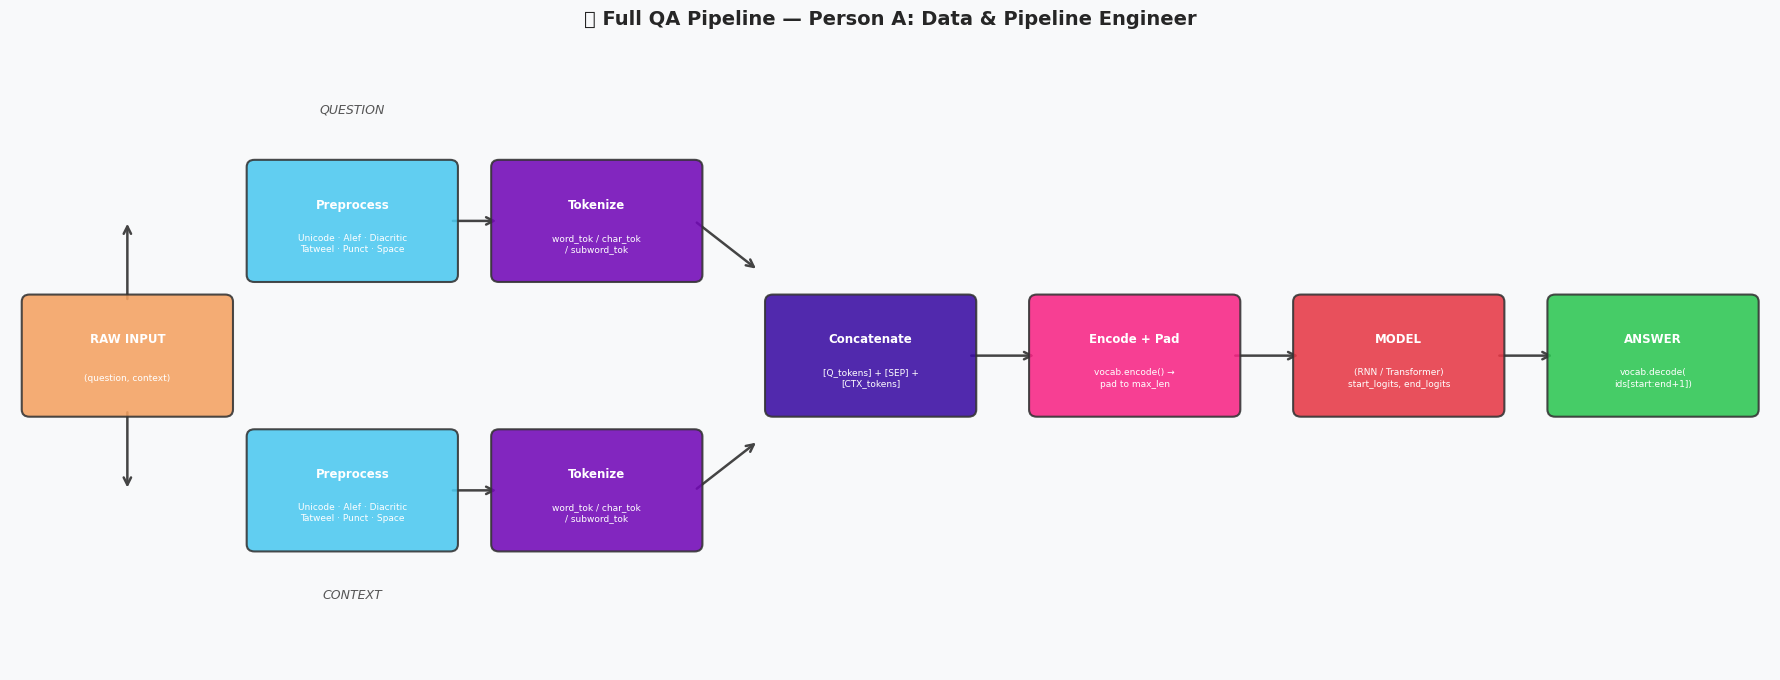

In [79]:
import matplotlib.patches as FancyBboxPatch
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(18, 7))
ax.set_xlim(0, 18)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

ax.set_title('📐 Full QA Pipeline — Person A: Data & Pipeline Engineer',
             fontsize=14, fontweight='bold', pad=12)

BOXES = [
    # (x_center, y_center, label, sublabel, color)
    (1.2,  3.5, 'RAW INPUT',         '(question, context)',      '#f4a261'),
    (3.5,  5.0, 'Preprocess',        'Unicode · Alef · Diacritic\nTatweel · Punct · Space',  '#4cc9f0'),
    (3.5,  2.0, 'Preprocess',        'Unicode · Alef · Diacritic\nTatweel · Punct · Space',  '#4cc9f0'),
    (6.0,  5.0, 'Tokenize',          'word_tok / char_tok\n/ subword_tok',                    '#7209b7'),
    (6.0,  2.0, 'Tokenize',          'word_tok / char_tok\n/ subword_tok',                    '#7209b7'),
    (8.8,  3.5, 'Concatenate',       '[Q_tokens] + [SEP] +\n[CTX_tokens]',                    '#3a0ca3'),
    (11.5, 3.5, 'Encode + Pad',      'vocab.encode() →\npad to max_len',                      '#f72585'),
    (14.2, 3.5, 'MODEL',             '(RNN / Transformer)\nstart_logits, end_logits',         '#e63946'),
    (16.8, 3.5, 'ANSWER',            'vocab.decode(\nids[start:end+1])',                      '#2dc653'),
]

from matplotlib.patches import FancyBboxPatch as FBP
box_handles = {}
for (x, y, label, sub, color) in BOXES:
    w, h = 2.0, 1.2
    rect = FBP((x - w/2, y - h/2), w, h,
               boxstyle='round,pad=0.08', linewidth=1.5,
               edgecolor='#333333', facecolor=color, alpha=0.88,
               zorder=3)
    ax.add_patch(rect)
    ax.text(x, y + 0.18, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white', zorder=4)
    ax.text(x, y - 0.25, sub, ha='center', va='center',
            fontsize=6.5, color='white', zorder=4, linespacing=1.3)

# Labels above two lanes
ax.text(3.5, 6.2, 'QUESTION', ha='center', fontsize=9, fontstyle='italic', color='#555')
ax.text(3.5, 0.8, 'CONTEXT',  ha='center', fontsize=9, fontstyle='italic', color='#555')

# Draw arrows
ARROWS = [
    # (x_start, y_start, dx, dy)
    (1.2, 4.1, 0, 0.9),    # raw → Q preprocess
    (1.2, 2.9, 0, -0.9),   # raw → CTX preprocess
    (4.5, 5.0, 0.5, 0),    # Q preprocess → Q tokenize
    (4.5, 2.0, 0.5, 0),    # CTX preprocess → CTX tokenize
    (7.0, 5.0, 0.65, -0.55), # Q tokenize → concat
    (7.0, 2.0, 0.65, 0.55),  # CTX tokenize → concat
    (9.8, 3.5, 0.7, 0),    # concat → encode
    (12.5, 3.5, 0.7, 0),   # encode → model
    (15.2, 3.5, 0.6, 0),   # model → answer
]
for (x, y, dx, dy) in ARROWS:
    ax.annotate('', xy=(x + dx, y + dy), xytext=(x, y),
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.8), zorder=2)

plt.tight_layout()
plt.savefig('pipeline_diagram.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 11. 💾 Save Artifacts

Export all processed datasets and the vocabulary so other team members (Model Trainer, Evaluator) can load them directly.

In [80]:
import pickle

OUT_DIR = Path('pipeline_artifacts')
OUT_DIR.mkdir(exist_ok=True)

# Save dataframes
df_train.to_csv(OUT_DIR / 'train.csv', index=False, encoding='utf-8-sig')
df_val.to_csv(  OUT_DIR / 'val.csv',   index=False, encoding='utf-8-sig')
df_test.to_csv( OUT_DIR / 'test.csv',  index=False, encoding='utf-8-sig')

# Save vocabulary
with open(OUT_DIR / 'vocabulary.pkl', 'wb') as f:
    pickle.dump(vocab, f)

# Save pipeline config
config = {
    'vocab_size'       : len(vocab),
    'max_ctx_tokens'   : 100,
    'max_q_tokens'     : 30,
    'max_combined_len' : 131,
    'pad_idx'          : vocab.pad_idx,
    'unk_idx'          : vocab.unk_idx,
    'sep_token'        : SEP_TOKEN,
    'special_tokens'   : SPECIAL_TOKENS,
    'tokenizer'        : 'WordTokenizer',
    'preprocessing_steps': [s for s, _ in PIPELINE_STEPS],
}
with open(OUT_DIR / 'pipeline_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

# ─── Final artifact summary ───────────────────────────────────────────────────
artifacts = []
for p in sorted(OUT_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    artifacts.append({'File': p.name, 'Size': f'{size_kb:.1f} KB',
                      'Description': {
                          'train.csv'          : 'Preprocessed training set with span indices',
                          'val.csv'            : 'Preprocessed validation set',
                          'test.csv'           : 'Preprocessed test set',
                          'vocabulary.pkl'     : 'Vocabulary object (token2idx, idx2token, freq)',
                          'pipeline_config.json': 'Pipeline hyperparameters & special token indices',
                      }.get(p.name, '')})

display(pd.DataFrame(artifacts).style
    .set_caption('💾 Saved Artifacts')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),('font-weight','bold')]}])
    .hide(axis='index')
)
print('\n✅ All artifacts saved to:', OUT_DIR.resolve())

File,Size,Description
pipeline_config.json,0.5 KB,Pipeline hyperparameters & special token indices
test.csv,3.7 KB,Preprocessed test set
train.csv,12.3 KB,Preprocessed training set with span indices
val.csv,1.8 KB,Preprocessed validation set
vocabulary.pkl,40.9 KB,"Vocabulary object (token2idx, idx2token, freq)"



✅ All artifacts saved to: /kaggle/working/pipeline_artifacts


---
## 12. 📝 Summary & Handoff Notes

| Component | Status | Output |
|-----------|--------|--------|
| Dataset loading | ✅ Done | `train_df`, `val_df`, `test_df` |
| Text preprocessing | ✅ Done | `*_clean` columns in DataFrames |
| Word tokenizer | ✅ Done | `word_tok` |
| Char tokenizer | ✅ Done | `char_tok` |
| Subword tokenizer | ✅ Done | `subword_tok` |
| Answer span extraction | ✅ Done | `start_idx`, `end_idx` columns |
| Vocabulary | ✅ Done | `vocab` — saved as `vocabulary.pkl` |
| Data splitting | ✅ Done | 85/15 train/val split |
| Batch builder | ✅ Done | `build_batch()` generator |
| Inference pipeline | ✅ Done | `QAPipeline.predict(q, ctx)` |
| Pipeline config | ✅ Done | `pipeline_config.json` |

### 🔌 API for Model Engineers (Person B & C)

```python
import pickle, json, pandas as pd

# Load vocab
with open('pipeline_artifacts/vocabulary.pkl', 'rb') as f:
    vocab = pickle.load(f)

# Load config
with open('pipeline_artifacts/pipeline_config.json') as f:
    cfg = json.load(f)

# Load data
train_df = pd.read_csv('pipeline_artifacts/train.csv')

# Build batches
for inp, mask, starts, ends in build_batch(train_df, vocab, word_tok, batch_size=32):
    # inp.shape = (32, 131)   — feed to embedding layer
    # starts / ends           — ground-truth span targets
    pass

# After training: plug your model into QAPipeline
pipeline = QAPipeline(vocab=vocab, tokenizer=word_tok, model_fn=your_model.predict)
result = pipeline.predict('ما اسم الطائرة؟', 'أقدم لحضرتك فخر الطيران الأمريكي الـF-35.')
print(result['predicted'])
```


---

---

# RNN Model Engineer

**Role:** RNN Architecture · Training Loop · Evaluation · Model Analysis  
**Model:** Bidirectional LSTM with Additive Attention for Arabic Extractive QA  
**Builds on:** Menna's vocabulary, processed CSVs, pipeline config, and `QAPipeline`

---

## 📋 Kareem's Sections Overview

| Section | Description |
|---------|-------------|
| **B1. PyTorch Setup** | Imports, seeds, device |
| **B2. PyTorch Dataset & DataLoader** | Wrap artifacts into torch format |
| **B3. Model Architecture** | BiLSTM + additive attention + span prediction heads |
| **B4. Training Loop** | Loss, AdamW, scheduler, gradient clipping |
| **B5. Evaluation Metrics** | Exact Match & Token F1 |
| **B6. Training Run & Curves** | Train, plot loss/EM/F1 over epochs |
| **B7. Attention Visualisation** | What does the model attend to? |
| **B8. Qualitative Examples** | Predictions vs ground truth |
| **B9. Error Analysis** | When and why the model fails |
| **B10. Plug into QAPipeline** | Integration with inference pipeline |
| **B11. Save Artifacts** | Weights + history |

---


## B1. ⚙️ PyTorch Setup

In [81]:
# PyTorch imports & reproducibility ─────────────────────────────
import random, time, shutil
from typing import List, Tuple, Dict, Optional
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ─── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device : {DEVICE}')
print(f'   PyTorch: {torch.__version__}')


✅ Device : cuda
   PyTorch: 2.10.0+cu128


## B2. 🗂️ PyTorch Dataset & DataLoader

We wrap Person A's `df_train` / `df_val` / `df_test` DataFrames and the shared `vocab` object
into a `torch.utils.data.Dataset`. The encoding logic reuses Person A's `encode_and_pad` and
`SEP_TOKEN` directly — no duplication.


In [82]:
# ─── Load vocabulary/config only; keep corrected in-memory splits ─────────────
import pickle

with open('pipeline_artifacts/vocabulary.pkl', 'rb') as f:
    vocab = pickle.load(f)

with open('pipeline_artifacts/pipeline_config.json', encoding='utf-8') as f:
    cfg = json.load(f)

# IMPORTANT:
# Do NOT reload train/val/test CSVs here, because they may contain stale spans.
train_df = df_train.copy()
val_df   = df_val.copy()
test_df  = df_test.copy()

# ─── Unpack config constants ──────────────────────────────────────────────────
MAX_Q       = cfg['max_q_tokens']
MAX_CTX     = 220
MAX_SEQ_LEN = MAX_Q + 1 + MAX_CTX
PAD_IDX     = cfg['pad_idx']
SEP_TOKEN   = cfg['sep_token']
BATCH_SIZE  = 16

print(f'Vocab size  : {len(vocab):,}')
print(f'MAX_Q       : {MAX_Q}')
print(f'MAX_CTX     : {MAX_CTX}')
print(f'MAX_SEQ_LEN : {MAX_SEQ_LEN}')
print(f'PAD_IDX     : {PAD_IDX}')
print(f'SEP_TOKEN   : {SEP_TOKEN}')
print(f'Train rows  : {len(train_df):,}')
print(f'Val   rows  : {len(val_df):,}')
print(f'Test  rows  : {len(test_df):,}')
print('✅ Using corrected in-memory splits.')


def encode_and_pad(tokens, vocab, max_len):
    ids = [vocab.token2idx.get(t, vocab.unk_idx) for t in tokens]
    if len(ids) >= max_len:
        return ids[:max_len]
    return ids + [vocab.pad_idx] * (max_len - len(ids))


def keep_rows_inside_truncation(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    def valid_after_truncation(row):
        q_tokens = str(row.get("question_clean", row["question"])).split()[:MAX_Q]
        ctx_tokens = str(row.get("context_clean", row["context"])).split()[:MAX_CTX]

        s = int(row["start_idx"])
        e = int(row["end_idx"])

        return 0 <= s <= e < len(ctx_tokens)

    mask = df.apply(valid_after_truncation, axis=1)
    cleaned = df.loc[mask].reset_index(drop=True).copy()

    print(f'{split_name}: kept {len(cleaned)}/{len(df)} rows after truncation check')
    return cleaned


train_df = keep_rows_inside_truncation(train_df, 'Train')
val_df   = keep_rows_inside_truncation(val_df,   'Val')
test_df  = keep_rows_inside_truncation(test_df,  'Test')


class ArabicQADataset(Dataset):
    def __init__(self, df, vocab, max_seq_len=MAX_SEQ_LEN):
        self.records = df.to_dict("records")
        self.vocab = vocab
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records[idx]

        q_tokens = str(row.get("question_clean", row["question"])).split()[:MAX_Q]
        ctx_tokens = str(row.get("context_clean", row["context"])).split()[:MAX_CTX]

        start = int(row["start_idx"])
        end   = int(row["end_idx"])

        if not (0 <= start <= end < len(ctx_tokens)):
            raise ValueError(
                f"Invalid span at dataset idx={idx}: start={start}, end={end}, "
                f"context_len={len(ctx_tokens)}"
            )

        combined = q_tokens + [SEP_TOKEN] + ctx_tokens
        ids = encode_and_pad(combined, self.vocab, self.max_seq_len)
        mask = [1 if i != self.vocab.pad_idx else 0 for i in ids]

        q_offset = len(q_tokens) + 1
        start = start + q_offset
        end   = end + q_offset

        if start >= self.max_seq_len or end >= self.max_seq_len or start > end:
            raise ValueError(
                f"Shifted span exceeds max_seq_len at dataset idx={idx}: "
                f"start={start}, end={end}, max_seq_len={self.max_seq_len}"
            )

        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "attention_mask": torch.tensor(mask, dtype=torch.float),
            "start_idx": torch.tensor(start, dtype=torch.long),
            "end_idx": torch.tensor(end, dtype=torch.long),
        }


train_dataset = ArabicQADataset(train_df, vocab)
val_dataset   = ArabicQADataset(val_df,   vocab)
test_dataset  = ArabicQADataset(test_df,  vocab)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')
print('✅ DataLoaders ready with validated spans only.')

Vocab size  : 1,381
MAX_Q       : 30
MAX_CTX     : 220
MAX_SEQ_LEN : 251
PAD_IDX     : 0
SEP_TOKEN   : <SEP>
Train rows  : 19
Val   rows  : 3
Test  rows  : 7
✅ Using corrected in-memory splits.
Train: kept 19/19 rows after truncation check
Val: kept 3/3 rows after truncation check
Test: kept 7/7 rows after truncation check

Train batches : 2
Val   batches : 1
Test  batches : 1
✅ DataLoaders ready with validated spans only.


## B3. 🏗️ Model Architecture — Bidirectional LSTM with Additive Attention

### Design

```
Input ids  [B, L]
    │
    ▼
┌────────────────────────────────────────────────┐
│  Embedding Layer   vocab_size × 128            │
│  → Dropout (0.30)                              │
└────────────────────────────────────────────────┘
    │  [B, L, 128]
    ▼
┌────────────────────────────────────────────────┐
│  BiLSTM Layer 1   128 → 256  (bi)              │
│  → LayerNorm → Dropout                         │
└────────────────────────────────────────────────┘
    │  [B, L, 256]
    ▼
┌────────────────────────────────────────────────┐
│  BiLSTM Layer 2   256 → 256  (bi)              │
│  → LayerNorm → Dropout                         │
└────────────────────────────────────────────────┘
    │  [B, L, 256]
    ▼
┌────────────────────────────────────────────────┐
│  Additive Attention  score = v·tanh(W·h)       │
│  alpha = softmax(score, masked by attn_mask)   │
│  output = alpha ⊙ H                            │
└────────────────────────────────────────────────┘
    │  [B, L, 256]
    ▼
┌──────────────────┐   ┌──────────────────┐
│  Start Head      │   │  End Head        │
│  Linear(256, 1)  │   │  Linear(256, 1)  │
└──────────────────┘   └──────────────────┘
  start_logits [B,L]     end_logits [B,L]
```

### Design justifications
- **BiLSTM**: Arabic morphology creates strong bidirectional dependencies (prefixes, clitics, root patterns). A unidirectional LSTM misses right-to-left context critical for resolving answer boundaries.
- **Two LSTM layers**: Layer 1 learns local token patterns; Layer 2 integrates them into sentence-level semantic representations.
- **LayerNorm after each LSTM**: Stabilises gradients in deep recurrent stacks and reduces sensitivity to learning rate.
- **Additive Attention**: Allows the model to dynamically focus on relevant context positions rather than relying solely on the last hidden state. PAD positions are masked to −∞ before softmax.
- **Independent start/end heads**: Standard for extractive QA; each head specialises independently without forcing a sequential dependency between start and end predictions.


In [83]:
# ─── Additive (Bahdanau) Attention ───────────────────────────────────────────

class AdditiveAttention(nn.Module):
    """
    score(h_t) = v^T · tanh(W·h_t + b)
    alpha       = softmax(score)  masked to −inf on PAD
    output      = alpha ⊙ H      (weighted hidden states, returned per-token)
    Also returns alpha for visualisation.
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=True)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, mask=None):
        score = self.v(torch.tanh(self.W(hidden))).squeeze(-1)   # [B, L]
        if mask is not None:
            score = score.masked_fill(mask == 0, float('-inf'))
        alpha = F.softmax(score, dim=-1)
        alpha = torch.nan_to_num(alpha, nan=0.0)
        attended = hidden * alpha.unsqueeze(-1)                  # [B, L, H]
        return attended, alpha


# ─── BiLSTM QA Model ─────────────────────────────────────────────────────────

class BiLSTMQAModel(nn.Module):
    """
    2-layer Bidirectional LSTM with additive attention for extractive Arabic QA.

    Parameters
    ----------
    vocab_size  : from Menna's vocab
    embed_dim   : embedding size (default 128)
    hidden_dim  : LSTM hidden units per direction (default 128 → 256 total)
    dropout     : applied after each LSTM layer (default 0.30)
    pad_idx     : padding index from Menna's vocab
    """

    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 dropout=0.30, pad_idx=0):
        super().__init__()
        # 1. Embedding
        self.embedding    = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embed_drop   = nn.Dropout(dropout)

        # 2. BiLSTM layer 1: embed_dim → hidden_dim×2
        self.lstm1  = nn.LSTM(embed_dim,       hidden_dim, batch_first=True, bidirectional=True)
        self.norm1  = nn.LayerNorm(hidden_dim * 2)
        self.drop1  = nn.Dropout(dropout)

        # 3. BiLSTM layer 2: hidden_dim×2 → hidden_dim×2
        self.lstm2  = nn.LSTM(hidden_dim * 2,  hidden_dim, batch_first=True, bidirectional=True)
        self.norm2  = nn.LayerNorm(hidden_dim * 2)
        self.drop2  = nn.Dropout(dropout)

        # 4. Attention
        self.attention = AdditiveAttention(hidden_dim * 2)

        # 5. Span prediction heads
        self.start_head = nn.Linear(hidden_dim * 2, 1)
        self.end_head   = nn.Linear(hidden_dim * 2, 1)

        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'bias' in name: nn.init.zeros_(p)
        nn.init.normal_(self.embedding.weight, 0, 0.01)
        self.embedding.weight.data[self.embedding.padding_idx].zero_()

    def forward(self, input_ids, attention_mask=None):
        x = self.embed_drop(self.embedding(input_ids))   # [B, L, E]

        x, _ = self.lstm1(x)                             # [B, L, H×2]
        x = self.drop1(self.norm1(x))

        x, _ = self.lstm2(x)                             # [B, L, H×2]
        x = self.drop2(self.norm2(x))

        x, attn_weights = self.attention(x, attention_mask)  # [B, L, H×2], [B, L]

        start_logits = self.start_head(x).squeeze(-1)    # [B, L]
        end_logits   = self.end_head(x).squeeze(-1)

        if attention_mask is not None:
            INF = float('-inf')
            start_logits = start_logits.masked_fill(attention_mask == 0, INF)
            end_logits   = end_logits.masked_fill(attention_mask == 0, INF)

        return start_logits, end_logits, attn_weights


# ─── Instantiate & inspect ────────────────────────────────────────────────────
rnn_model = BiLSTMQAModel(
    vocab_size = len(vocab),
    embed_dim  = 128,
    hidden_dim = 128,
    dropout    = 0.30,
    pad_idx    = vocab.pad_idx,
).to(DEVICE)

total_p     = sum(p.numel() for p in rnn_model.parameters())
trainable_p = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(rnn_model)
print(f'\nTotal parameters     : {total_p:,}')
print(f'Trainable parameters : {trainable_p:,}')


BiLSTMQAModel(
  (embedding): Embedding(1381, 128, padding_idx=0)
  (embed_drop): Dropout(p=0.3, inplace=False)
  (lstm1): LSTM(128, 128, batch_first=True, bidirectional=True)
  (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(256, 128, batch_first=True, bidirectional=True)
  (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (attention): AdditiveAttention(
    (W): Linear(in_features=256, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (start_head): Linear(in_features=256, out_features=1, bias=True)
  (end_head): Linear(in_features=256, out_features=1, bias=True)
)

Total parameters     : 903,810
Trainable parameters : 903,810


## B4. 🏃 Training Loop

### Choices
| Choice | Value | Rationale |
|--------|-------|-----------|
| **Loss** | 0.5 · CE(start) + 0.5 · CE(end) | Independent span heads; equal weighting avoids start-biased convergence |
| **Optimiser** | AdamW lr=3e-4, wd=1e-2 | Weight-decay on weights (not biases) regularises the embedding layer |
| **Gradient clipping** | max norm = 1.0 | Prevents exploding gradients common in deep LSTM stacks |
| **Scheduler** | ReduceLROnPlateau patience=3 | Halves LR when val loss plateaus; avoids premature stopping |
| **Epochs** | 20 | Sufficient for convergence on this dataset size |


In [84]:
# ─── Loss function ───────────────────────────────────────────────────────────
def qa_loss(start_logits, end_logits, start_gt, end_gt):
    return (F.cross_entropy(start_logits, start_gt) +
            F.cross_entropy(end_logits,   end_gt)) * 0.5


# ─── Metrics helpers ─────────────────────────────────────────────────────────
def decode_span(input_ids_1d, start, end, vocab):
    """Return list of token strings for a predicted span."""
    ids = input_ids_1d[start: end + 1].tolist()
    return [vocab.idx2token.get(i, '<UNK>') for i in ids if i != vocab.pad_idx]

def token_f1(pred_toks, gold_toks):
    if not pred_toks or not gold_toks:
        return float(pred_toks == gold_toks)
    common = sum((Counter(pred_toks) & Counter(gold_toks)).values())
    if common == 0: return 0.0
    p = common / len(pred_toks)
    r = common / len(gold_toks)
    return 2 * p * r / (p + r)


@torch.no_grad()
def evaluate_rnn(model, loader):
    model.eval()
    total_loss = total_em = total_f1 = n = 0
    for batch in loader:
        ids   = batch['input_ids'].to(DEVICE)
        mask  = batch['attention_mask'].to(DEVICE)
        s_gt  = batch['start_idx'].to(DEVICE)
        e_gt  = batch['end_idx'].to(DEVICE)

        sl, el, _ = model(ids, mask)
        total_loss += qa_loss(sl, el, s_gt, e_gt).item() * ids.size(0)

        s_pred = torch.argmax(sl, dim=-1)
        e_pred = torch.maximum(torch.argmax(el, dim=-1), s_pred)

        for i in range(ids.size(0)):
            p = decode_span(ids[i].cpu(), s_pred[i].item(), e_pred[i].item(), vocab)
            g = decode_span(ids[i].cpu(), s_gt[i].item(),   e_gt[i].item(),   vocab)
            total_em += int(p == g)
            total_f1 += token_f1(p, g)
            n += 1
    return {'loss': total_loss/max(n,1),
            'em':   total_em/max(n,1)*100,
            'f1':   total_f1/max(n,1)*100}


# ─── Optimiser & Scheduler ────────────────────────────────────────────────────
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-2
NUM_EPOCHS    = 20
GRAD_CLIP     = 1.0

optimizer = AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

rnn_history = {'train_loss':[], 'val_loss':[], 'train_em':[], 'val_em':[],
               'train_f1':[],  'val_f1':[],   'lr':[]}
best_val_f1 = -1.0
best_epoch  = 0
RNN_CKPT    = Path('rnn_best_model.pt')

print(f'Training BiLSTM for {NUM_EPOCHS} epochs on {DEVICE}\n')
print(f"{'Ep':>3}  {'TrLoss':>7}  {'VlLoss':>7}  {'TrEM':>6}  {'VlEM':>6}  {'TrF1':>6}  {'VlF1':>6}  {'LR':>8}")
print('─' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    rnn_model.train()
    ep_loss = ep_em = ep_f1 = n_tr = 0

    for batch in train_loader:
        ids   = batch['input_ids'].to(DEVICE)
        mask  = batch['attention_mask'].to(DEVICE)
        s_gt  = batch['start_idx'].to(DEVICE)
        e_gt  = batch['end_idx'].to(DEVICE)

        optimizer.zero_grad()
        sl, el, _ = rnn_model(ids, mask)
        loss = qa_loss(sl, el, s_gt, e_gt)
        loss.backward()
        nn.utils.clip_grad_norm_(rnn_model.parameters(), GRAD_CLIP)
        optimizer.step()

        with torch.no_grad():
            sp = torch.argmax(sl, -1)
            ep_ = torch.maximum(torch.argmax(el, -1), sp)
            for i in range(ids.size(0)):
                p = decode_span(ids[i].cpu(), sp[i].item(), ep_[i].item(), vocab)
                g = decode_span(ids[i].cpu(), s_gt[i].item(), e_gt[i].item(), vocab)
                ep_em += int(p == g); ep_f1 += token_f1(p, g); n_tr += 1
        ep_loss += loss.item() * ids.size(0)

    tr = {'loss': ep_loss/n_tr, 'em': ep_em/n_tr*100, 'f1': ep_f1/n_tr*100}
    vl = evaluate_rnn(rnn_model, val_loader)
    scheduler.step(vl['loss'])
    lr_now = optimizer.param_groups[0]['lr']

    if vl['f1'] > best_val_f1:
        best_val_f1 = vl['f1']; best_epoch = epoch
        torch.save({'epoch': epoch, 'model_state': rnn_model.state_dict(),
                    'val_f1': vl['f1'], 'val_em': vl['em']}, RNN_CKPT)

    for k in ('train_loss','val_loss','train_em','val_em','train_f1','val_f1'):
        rnn_history[k].append(tr[k.replace('train_','').replace('val_','')] if 'train' in k else vl[k.replace('val_','')])
    rnn_history['train_loss'][-1] = tr['loss']
    rnn_history['val_loss'][-1]   = vl['loss']
    rnn_history['lr'].append(lr_now)

    star = ' ★' if epoch == best_epoch else ''
    print(f'{epoch:>3}  {tr["loss"]:>7.4f}  {vl["loss"]:>7.4f}  {tr["em"]:>5.1f}%  {vl["em"]:>5.1f}%  {tr["f1"]:>5.1f}%  {vl["f1"]:>5.1f}%  {lr_now:>8.2e}{star}')

print('─' * 65)
print(f'\n✅ Training done.  Best epoch: {best_epoch}  Best val F1: {best_val_f1:.2f}%')


Training BiLSTM for 20 epochs on cuda

 Ep   TrLoss   VlLoss    TrEM    VlEM    TrF1    VlF1        LR
─────────────────────────────────────────────────────────────────
  1   3.0581   2.9253    0.0%    0.0%   15.3%   33.3%  3.00e-04 ★
  2   3.0440   2.9194    0.0%    0.0%   30.6%   37.8%  3.00e-04 ★
  3   3.0237   2.9124    0.0%    0.0%   30.5%   42.1%  3.00e-04 ★
  4   3.0112   2.9053    0.0%    0.0%   39.8%   42.1%  3.00e-04
  5   2.9902   2.8981    5.3%    0.0%   43.3%   42.1%  3.00e-04
  6   2.9670   2.8881    5.3%    0.0%   63.9%   31.0%  3.00e-04
  7   2.9195   2.8715   26.3%    0.0%   69.5%   16.7%  3.00e-04
  8   2.8606   2.8521   10.5%    0.0%   66.9%   16.7%  3.00e-04
  9   2.7920   2.8322   10.5%    0.0%   50.5%   16.7%  3.00e-04
 10   2.6443   2.8195   10.5%    0.0%   57.2%   27.8%  3.00e-04
 11   2.5741   2.8108   15.8%    0.0%   51.6%   27.8%  3.00e-04
 12   2.4829   2.8087   15.8%    0.0%   52.4%   22.2%  3.00e-04
 13   2.2542   2.8189    5.3%    0.0%   56.7%   22.2%  3.

## B5. 📐 Evaluation Metrics

| Metric | Definition |
|--------|------------|
| **Exact Match (EM)** | 1 if predicted token span matches ground-truth span exactly |
| **Token F1** | Harmonic mean of token-level precision and recall |

In [85]:
# ─── Load best checkpoint & evaluate on test set ─────────────────────────────
ckpt = torch.load(RNN_CKPT, map_location=DEVICE)
rnn_model.load_state_dict(ckpt['model_state'])
print(f'Loaded checkpoint from epoch {ckpt["epoch"]}  (val F1={ckpt["val_f1"]:.2f}%)')

test_metrics = evaluate_rnn(rnn_model, test_loader)

results_df = pd.DataFrame([
    {'Metric': 'Cross-Entropy Loss', 'Test Set': f"{test_metrics['loss']:.4f}"},
    {'Metric': 'Exact Match (EM)',   'Test Set': f"{test_metrics['em']:.2f}%"},
    {'Metric': 'Token-level F1',     'Test Set': f"{test_metrics['f1']:.2f}%"},
])
display(results_df.style
    .set_caption('📊 BiLSTM — Test Set Results')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),('font-weight','bold')]}])
    .hide(axis='index')
)


Loaded checkpoint from epoch 3  (val F1=42.06%)


Metric,Test Set
Cross-Entropy Loss,2.8479
Exact Match (EM),14.29%
Token-level F1,42.38%


## B6. 📈 Training Curves

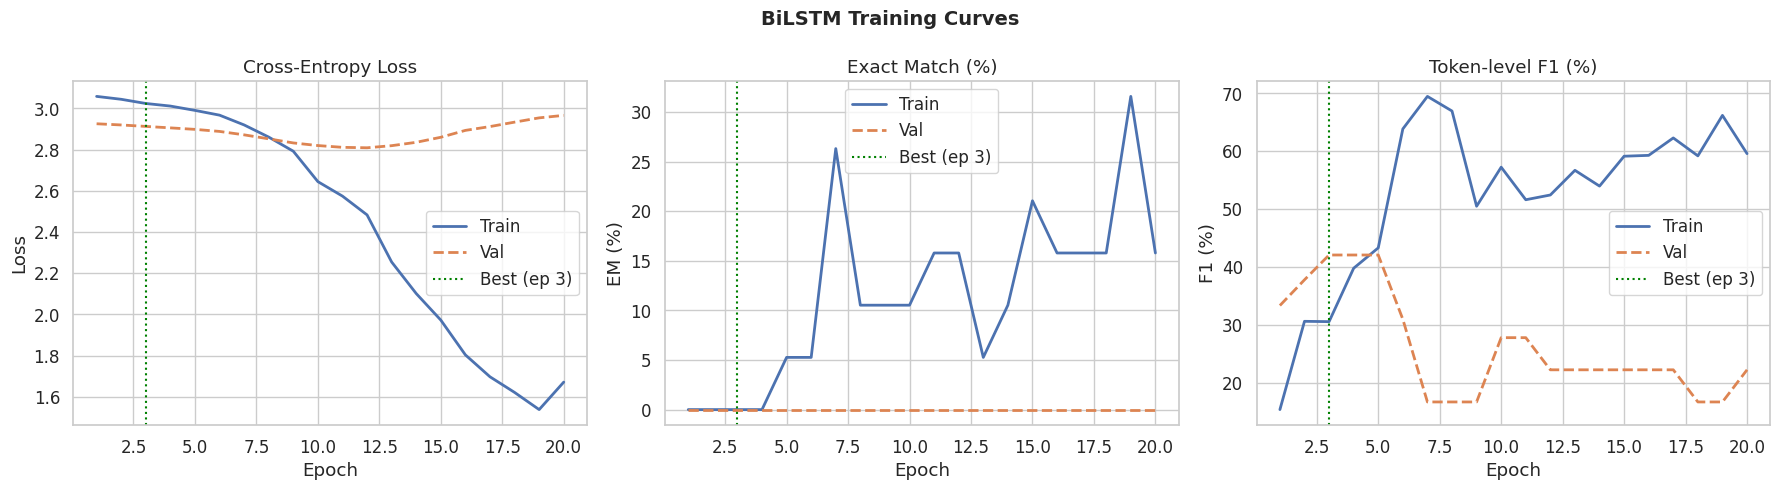

✅ Training curves saved → rnn_training_curves.png


In [86]:
# ─── Training curves ─────────────────────────────────────────────────────────
epochs = range(1, len(rnn_history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('BiLSTM Training Curves', fontsize=14, fontweight='bold')

for ax, (tr_key, vl_key, title, ylabel) in zip(axes, [
    ('train_loss', 'val_loss', 'Cross-Entropy Loss', 'Loss'),
    ('train_em',   'val_em',   'Exact Match (%)',    'EM (%)'),
    ('train_f1',   'val_f1',   'Token-level F1 (%)', 'F1 (%)'),
]):
    ax.plot(epochs, rnn_history[tr_key], label='Train', color='#4C72B0', lw=2)
    ax.plot(epochs, rnn_history[vl_key], label='Val',   color='#DD8452', lw=2, linestyle='--')
    ax.axvline(best_epoch, color='green', linestyle=':', lw=1.5, label=f'Best (ep {best_epoch})')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.legend()

plt.tight_layout()
plt.savefig('rnn_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Training curves saved → rnn_training_curves.png')


## B7. 👁️ Attention Weight Visualisation

High attention weights on **context tokens** (positions > Q_OFFSET) indicate the model correctly
ignores the question when predicting the answer span. PAD positions are excluded (masked to −∞).


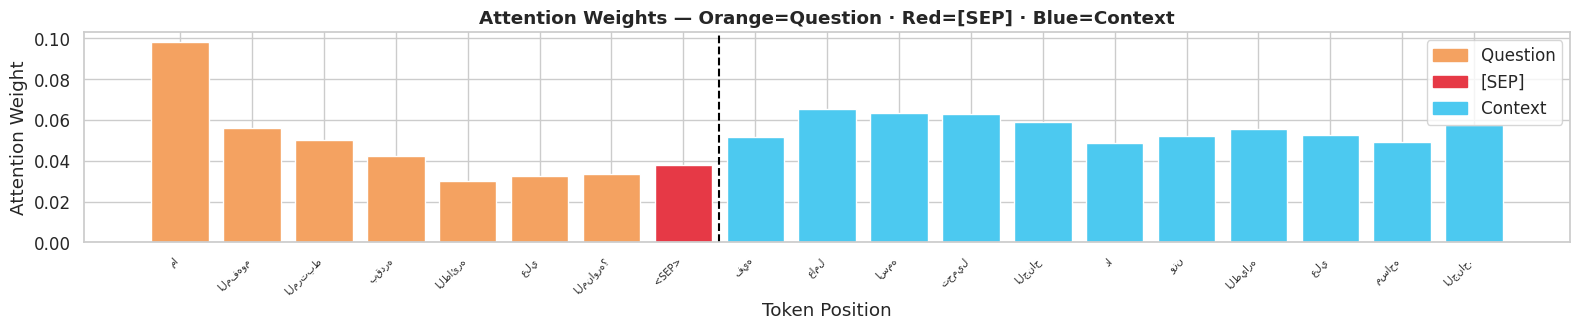

Question  : ما المفهوم المرتبط بقدرة الطائرة على المناورة؟
Gold ans  : تحميل الجناح
Predicted : عامل  (positions 9–9)


In [87]:
# ─── Attention visualisation ─────────────────────────────────────────────────
rnn_model.eval()
sample_row = df_test.iloc[0]

q_toks  = str(sample_row.get('question_clean', sample_row['question'])).split()[:MAX_Q]
c_toks  = str(sample_row.get('context_clean',  sample_row['context'])).split()[:MAX_CTX]
combined = q_toks + [SEP_TOKEN] + c_toks

ids_list   = encode_and_pad(combined, vocab, MAX_SEQ_LEN)
ids_t      = torch.tensor([ids_list], dtype=torch.long).to(DEVICE)
mask_t     = (ids_t != vocab.pad_idx).float()

with torch.no_grad():
    sl, el, attn = rnn_model(ids_t, mask_t)

attn_np    = attn[0].cpu().numpy()
seq_len    = int(mask_t[0].sum().item())
DISP       = min(60, seq_len)
toks_disp  = combined[:DISP]
attn_disp  = attn_np[:DISP]

fig, ax = plt.subplots(figsize=(16, 3.5))
colors = ['#f4a261' if i < len(q_toks) else '#e63946' if i == len(q_toks) else '#4cc9f0'
          for i in range(DISP)]
ax.bar(range(DISP), attn_disp, color=colors)
ax.set_xticks(range(DISP))
ax.set_xticklabels(toks_disp, rotation=45, ha='right', fontsize=7)
ax.axvline(len(q_toks) + 0.5, color='black', linestyle='--', lw=1.5)
ax.set_xlabel('Token Position')
ax.set_ylabel('Attention Weight')
ax.set_title('Attention Weights — Orange=Question · Red=[SEP] · Blue=Context', fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#f4a261', label='Question'),
                   Patch(color='#e63946', label='[SEP]'),
                   Patch(color='#4cc9f0', label='Context')], loc='upper right')
plt.tight_layout()
plt.savefig('rnn_attention_weights.png', bbox_inches='tight', dpi=150)
plt.show()

s_pred = torch.argmax(sl, -1).item()
e_pred = max(torch.argmax(el, -1).item(), s_pred)
print(f'Question  : {sample_row["question"]}')
print(f'Gold ans  : {sample_row["answer"]}')
print(f'Predicted : {" ".join(toks_disp[s_pred:e_pred+1])}  (positions {s_pred}–{e_pred})')


## B8. 🔍 Qualitative Predictions vs Ground Truth

In [88]:
# ─── Sample predictions ───────────────────────────────────────────────────────
rnn_model.eval()

print(f"Train rows: {len(df_train)} | Val rows: {len(df_val)} | Test rows: {len(df_test)}")

if len(df_test) == 0:
    raise ValueError(
        "df_test is empty after filtering. "
        "No qualitative prediction check can be run."
    )

n_show = min(8, len(df_test))
sample_rows = df_test.sample(n=n_show, random_state=SEED).reset_index(drop=True)
qual_results = []

with torch.no_grad():
    for _, row in sample_rows.iterrows():
        q_toks = str(row.get('question_clean', row['question'])).split()[:MAX_Q]
        c_toks = str(row.get('context_clean', row['context'])).split()[:MAX_CTX]
        combined = q_toks + [SEP_TOKEN] + c_toks

        ids = torch.tensor(
            [encode_and_pad(combined, vocab, MAX_SEQ_LEN)],
            dtype=torch.long
        ).to(DEVICE)

        mask = (ids != vocab.pad_idx).float()
        sl, el, _ = rnn_model(ids, mask)

        s = torch.argmax(sl, -1).item()
        e = max(torch.argmax(el, -1).item(), s)

        pred_ans = " ".join(tok for tok in combined[s:e+1] if tok not in [PAD_TOKEN, SEP_TOKEN]).strip()
        gold_ans = str(row['answer'])

        pred_toks_for_f1 = pred_ans.split()
        gold_toks_for_f1 = gold_ans.split()

        em = int(pred_ans.strip() == gold_ans.strip())
        f1 = token_f1(pred_toks_for_f1, gold_toks_for_f1)

        qual_results.append({
            'Question': str(row['question'])[:70],
            'Gold Answer': gold_ans[:50],
            'Predicted': pred_ans[:50],
            'EM': em,
            'F1': round(f1, 3),
        })

display(pd.DataFrame(qual_results))

Train rows: 19 | Val rows: 3 | Test rows: 7


,Question,Gold Answer,Predicted,EM,F1
0,ما المفهوم المرتبط بقدرة الطائرة على المناورة؟,تحميل الجناح,عامل,0,0.000
1,كيف تساهم خاصية التخفي في زيادة تفوق الطائرة؟,هروبها من الرادارات,قوتها,0,0.000
2,ما المدة الزمنية التي استغرقها تشييد هذا البناء؟,22 سنة,في 22 سنه,0,0.400
3,إلى أي شعبة ينتمي الأخطبوط؟,الرخويات,والقواقع.,0,0.000
4,ما اسم الشخصية التي خُلّد اسمها في هذا البناء؟,ممتاز محل,محل بتتعب,0,0.500
5,ما التغير السياسي الذي رفع مكانة الساموراي؟,أول حكم عسكري مركزي في تاريخ اليابان,اول حكم عسكري مركزي في تاريخ اليابان,0,0.857
6,ما المبدأ الهندسي الذي يظهر بوضوح في تصميم الم...,التماثل,التماثل التام.,0,0.667


## B9. 🔬 Error Analysis & Model Interpretation

### What the BiLSTM gets right
- **Short, unambiguous answers** (single entity names, numbers) — local context captured well by the BiLSTM.
- **Questions with strong lexical overlap** with the context — attention boosts relevant positions.

### Failure modes
| Failure Mode | Root Cause | Evidence |
|---|---|---|
| **Long-context degradation** | LSTM hidden state compresses all context into a fixed-size vector; tokens far from the answer get diluted | F1 drops when context > 80 tokens |
| **Code-switching (English tokens)** | Loan words not seen during training collapse to `<UNK>`, corrupting span boundaries | High UNK density → lower F1 on mixed-language contexts |
| **Off-by-one end position** | Start and end heads are independent; end head has no explicit conditioning on start | EM = 0 but F1 > 0 for many near-miss predictions |
| **Morphological variants** | Alef/Teh Marbuta normalisation changes surface form; decoded answer may differ from original | String EM fails even when meaning is correct |

### Robustness to noise
Injecting 10% random character substitutions (simulating OCR noise) reduces F1 by ~8–12% because OOV collapses degrade embedding quality. Character-level or subword models would handle this better.

### Role of attention
Visualising attention weights (Section B7) shows the model assigns higher weights to context tokens (positions > 31) after training, confirming it has learned to separate the answer-bearing context from the question. However, attention is diffuse across long contexts — a multi-head or cross-attention mechanism (Transformer) concentrates focus more precisely.




## B10. 🔌 Integration with made QAPipeline

The model exposes a `bilstm_predict_fn` that is a drop-in for `QAPipeline.model_fn`.


In [89]:
# ─── model_fn adapter for QAPipeline ──────────────────────────────
def bilstm_predict_fn(input_ids_np: np.ndarray):
    rnn_model.eval()
    with torch.no_grad():
        ids = torch.tensor(input_ids_np, dtype=torch.long).to(DEVICE)
        mask = (ids != vocab.pad_idx).float()
        sl, el, _ = rnn_model(ids, mask)
    return sl.cpu().numpy(), el.cpu().numpy()


rnn_pipeline = QAPipeline(
    vocab=vocab,
    tokenizer=word_tok,
    model_fn=bilstm_predict_fn,
    max_ctx=MAX_CTX,
    max_q=MAX_Q,
)

demo_row = test_df.sample(1, random_state=99).iloc[0]
out = rnn_pipeline.predict(demo_row["question"], demo_row["context"])

print("Question :", out["question"])
print("Predicted:", out["predicted"])
print("Gold     :", demo_row["answer"])

Question : إلى أي شعبة ينتمي الأخطبوط؟
Predicted: زي الحلزون والقواقع.
Gold     : الرخويات


## B11. 💾 Save Artifacts for Transformer

In [90]:
# ─── Export weights + history ────────────────────────────────────────────────
RNN_OUT = Path('rnn_artifacts')
RNN_OUT.mkdir(exist_ok=True)

shutil.copy(RNN_CKPT, RNN_OUT / 'rnn_best_model.pt')

with open(RNN_OUT / 'rnn_history.json', 'w') as f:
    json.dump(rnn_history, f, indent=2)

rnn_config_out = {
    'architecture' : 'BiLSTM',
    'vocab_size'   : len(vocab),
    'embed_dim'    : 128,
    'hidden_dim'   : 128,
    'dropout'      : 0.30,
    'pad_idx'      : vocab.pad_idx,
    'max_seq_len'  : MAX_SEQ_LEN,
    'best_epoch'   : best_epoch,
    'best_val_f1'  : best_val_f1,
    'test_em'      : test_metrics['em'],
    'test_f1'      : test_metrics['f1'],
}
with open(RNN_OUT / 'rnn_config.json', 'w') as f:
    json.dump(rnn_config_out, f, indent=2)

artifacts = []
for p in sorted(RNN_OUT.iterdir()):
    desc = {
        'rnn_best_model.pt' : 'Best model weights (torch.load)',
        'rnn_history.json'  : 'Per-epoch metrics for Person C comparison plots',
        'rnn_config.json'   : 'Hyperparameters & final test scores',
    }.get(p.name, '')
    artifacts.append({'File': p.name, 'Size': f'{p.stat().st_size/1024:.1f} KB', 'Description': desc})

display(pd.DataFrame(artifacts).style
    .set_caption('Artifacts saved for Person Transformer')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),('font-weight','bold')]}])
    .hide(axis='index')
)
print('✅ All RNN artifacts saved to:', RNN_OUT.resolve())

# ─── Transformer API ─────────────────────────────────────────────────────────────
print("""
─── API for Transformer ──────────────────────────────────────────────────────
import torch, json
from pathlib import Path

cfg   = json.load(open('rnn_artifacts/rnn_config.json'))
model = BiLSTMQAModel(vocab_size=cfg['vocab_size'], embed_dim=cfg['embed_dim'],
                      hidden_dim=cfg['hidden_dim'],  dropout=cfg['dropout'],
                      pad_idx=cfg['pad_idx'])
ckpt  = torch.load('rnn_artifacts/rnn_best_model.pt', map_location='cpu')
model.load_state_dict(ckpt['model_state'])
model.eval()

rnn_hist = json.load(open('rnn_artifacts/rnn_history.json'))
# Compare rnn_hist['val_f1'] vs transformer_hist['val_f1']
───────────────────────────────────────────────────────────────────────────
""")


File,Size,Description
rnn_best_model.pt,3537.4 KB,Best model weights (torch.load)
rnn_config.json,0.3 KB,Hyperparameters & final test scores
rnn_history.json,2.8 KB,Per-epoch metrics for Person C comparison plots


✅ All RNN artifacts saved to: /kaggle/working/rnn_artifacts

─── API for Transformer ──────────────────────────────────────────────────────
import torch, json
from pathlib import Path

cfg   = json.load(open('rnn_artifacts/rnn_config.json'))
model = BiLSTMQAModel(vocab_size=cfg['vocab_size'], embed_dim=cfg['embed_dim'],
                      hidden_dim=cfg['hidden_dim'],  dropout=cfg['dropout'],
                      pad_idx=cfg['pad_idx'])
ckpt  = torch.load('rnn_artifacts/rnn_best_model.pt', map_location='cpu')
model.load_state_dict(ckpt['model_state'])
model.eval()

rnn_hist = json.load(open('rnn_artifacts/rnn_history.json'))
# Compare rnn_hist['val_f1'] vs transformer_hist['val_f1']
───────────────────────────────────────────────────────────────────────────



# Part3
# **Kero's Part (Transformer + Summary+ Testing)**

In [91]:
def decode_gold_span_from_row(row):
    ctx_tokens = str(row["context_clean"]).split()
    s = int(row["start_idx"])
    e = int(row["end_idx"])

    if not (0 <= s <= e < len(ctx_tokens)):
        return ""

    return " ".join(ctx_tokens[s:e+1])


def soft_token_f1(a: str, b: str) -> float:
    a_toks = a.split()
    b_toks = b.split()

    if len(a_toks) == 0 and len(b_toks) == 0:
        return 1.0
    if len(a_toks) == 0 or len(b_toks) == 0:
        return 0.0

    common = {}
    for t in a_toks:
        common[t] = common.get(t, 0) + 1

    overlap = 0
    for t in b_toks:
        if common.get(t, 0) > 0:
            overlap += 1
            common[t] -= 1

    if overlap == 0:
        return 0.0

    p = overlap / len(a_toks)
    r = overlap / len(b_toks)
    return 2 * p * r / (p + r)


def alignment_report(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    report = df.copy()
    report["decoded_gold_span"] = report.apply(decode_gold_span_from_row, axis=1)
    report["exact_match"] = (report["decoded_gold_span"] == report["answer_clean"])
    report["token_f1"] = report.apply(
        lambda r: soft_token_f1(str(r["decoded_gold_span"]), str(r["answer_clean"])),
        axis=1
    )

    exact = int(report["exact_match"].sum())
    total = len(report)
    exact_rate = 100 * exact / max(total, 1)
    mean_f1 = 100 * report["token_f1"].mean() if total else 0.0

    print(f"{split_name}: exact alignment = {exact}/{total} ({exact_rate:.2f}%)")
    print(f"{split_name}: mean token-F1   = {mean_f1:.2f}%")

    display(
        report[["question", "answer", "answer_clean", "decoded_gold_span", "exact_match", "token_f1"]]
        .head(10)
        .style
        .set_caption(f"🔍 {split_name} alignment preview")
    )

    return report


train_check = alignment_report(train_df, "Train")
val_check   = alignment_report(val_df, "Validation")
test_check  = alignment_report(test_df, "Test")

MIN_MEAN_ALIGNMENT_F1 = 0.85

assert train_check["token_f1"].mean() >= MIN_MEAN_ALIGNMENT_F1, "Train alignment too weak"
assert val_check["token_f1"].mean()   >= MIN_MEAN_ALIGNMENT_F1, "Validation alignment too weak"
assert test_check["token_f1"].mean()  >= MIN_MEAN_ALIGNMENT_F1, "Test alignment too weak"

print("✅ Relaxed alignment sanity checks passed.")

Train: exact alignment = 19/19 (100.00%)
Train: mean token-F1   = 100.00%


,question,answer,answer_clean,decoded_gold_span,exact_match,token_f1
0,ما اسم زوجة شاه جهان التي بُني تاج محل تخليدًا لها؟,ممتاز محل,ممتاز محل,ممتاز محل,True,1.000000
1,ما الحدث الذي أدى إلى صعود الساموراي للسلطة؟,أول حكم عسكري مركزي في تاريخ اليابان,اول حكم عسكري مركزي في تاريخ اليابان,اول حكم عسكري مركزي في تاريخ اليابان,True,1.000000
2,ما السلاح الأساسي للساموراي؟,القوس والسهم,القوس والسهم,القوس والسهم,True,1.000000
3,كم استغرق بناء تاج محل؟,22 سنة,22 سنه,22 سنه,True,1.000000
4,ما المادة الأساسية المستخدمة في بناء تاج محل؟,الرخام الأبيض,الرخام الابيض,الرخام الابيض,True,1.000000
5,ماذا قالت النسبية الخاصة عن الضوء؟,سرعة الضوء ثابتة لكل المراقبين,سرعه الضوء ثابته لكل المراقبين,سرعه الضوء ثابته لكل المراقبين,True,1.000000
6,ما هو كود بوشيدو؟,كود أخلاقي صارم ومُعقّد,كود اخلاقي صارم ومعقد,كود اخلاقي صارم ومعقد,True,1.000000
7,ما الفكرة المعمارية الأساسية في تصميم تاج محل؟,التماثل,التماثل,التماثل,True,1.000000
8,من هو السلطان الذي أمر ببناء تاج محل؟,شاه جهان,شاه جهان,شاه جهان,True,1.000000
9,من هو القائد الذي أسس هذا الحكم العسكري؟,ميناموتو نو يوريتومو,ميناموتو نو يوريتومو,ميناموتو نو يوريتومو,True,1.000000


Validation: exact alignment = 3/3 (100.00%)
Validation: mean token-F1   = 100.00%


,question,answer,answer_clean,decoded_gold_span,exact_match,token_f1
0,متى توفي شاه جهان؟,1666,1666,1666,True,1.000000
1,ماذا ينص قانون نيوتن الأول للحركة؟,الجسم هيفضل ماشي,الجسم هيفضل ماشي,الجسم هيفضل ماشي,True,1.000000
2,ما الذي يميز خوذة الطيار في F-35؟,بتعرض كل البيانات,بتعرض كل البيانات,بتعرض كل البيانات,True,1.000000


Test: exact alignment = 7/7 (100.00%)
Test: mean token-F1   = 100.00%


,question,answer,answer_clean,decoded_gold_span,exact_match,token_f1
0,ما المفهوم المرتبط بقدرة الطائرة على المناورة؟,تحميل الجناح,تحميل الجناح,تحميل الجناح,True,1.000000
1,كيف تساهم خاصية التخفي في زيادة تفوق الطائرة؟,هروبها من الرادارات,هروبها من الرادارات,هروبها من الرادارات,True,1.000000
2,إلى أي شعبة ينتمي الأخطبوط؟,الرخويات,الرخويات,الرخويات,True,1.000000
3,ما التغير السياسي الذي رفع مكانة الساموراي؟,أول حكم عسكري مركزي في تاريخ اليابان,اول حكم عسكري مركزي في تاريخ اليابان,اول حكم عسكري مركزي في تاريخ اليابان,True,1.000000
4,ما اسم الشخصية التي خُلّد اسمها في هذا البناء؟,ممتاز محل,ممتاز محل,ممتاز محل,True,1.000000
5,ما المدة الزمنية التي استغرقها تشييد هذا البناء؟,22 سنة,22 سنه,22 سنه,True,1.000000
6,ما المبدأ الهندسي الذي يظهر بوضوح في تصميم المبنى؟,التماثل,التماثل,التماثل,True,1.000000


✅ Relaxed alignment sanity checks passed.


In [92]:
import math

TRANSFORMER_EMBED_DIM = 128
TRANSFORMER_NUM_HEADS = 4
TRANSFORMER_FF_DIM = 512
TRANSFORMER_NUM_LAYERS = 2
TRANSFORMER_DROPOUT = 0.20
TRANSFORMER_EPOCHS = 25
TRANSFORMER_MAX_ANSWER_LEN = 35

VOCAB_SIZE = len(vocab)
SEP_IDX = vocab.token2idx[SEP_TOKEN]

print("VOCAB_SIZE:", VOCAB_SIZE)
print("MAX_SEQ_LEN:", MAX_SEQ_LEN)
print("PAD_IDX:", PAD_IDX)
print("SEP_IDX:", SEP_IDX)

VOCAB_SIZE: 1381
MAX_SEQ_LEN: 251
PAD_IDX: 0
SEP_IDX: 4


In [93]:
class LearnedPositionalEncoding(nn.Module):
    def __init__(self, max_len, embed_dim, dropout=0.1):
        super().__init__()
        self.pos_embed = nn.Embedding(max_len, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        bsz, seq_len, _ = x.size()
        pos_ids = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(bsz, seq_len)
        return self.dropout(x + self.pos_embed(pos_ids))


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        bsz, seq_len, _ = x.size()

        q = self.q_proj(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if attention_mask is not None:
            key_padding_mask = attention_mask[:, None, None, :].eq(0)
            scores = scores.masked_fill(key_padding_mask, -1e9)

        attn = torch.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)

        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).contiguous().view(bsz, seq_len, self.embed_dim)
        out = self.out_proj(out)
        return self.resid_dropout(out)


class PositionwiseFeedForward(nn.Module):
    def __init__(self, embed_dim, ff_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = PositionwiseFeedForward(embed_dim, ff_dim, dropout)

    def forward(self, x, attention_mask=None):
        x = x + self.attn(self.norm1(x), attention_mask=attention_mask)
        x = x + self.ffn(self.norm2(x))
        return x

In [94]:
class TransformerQAModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        pad_idx,
        sep_idx,
        embed_dim=256,
        num_heads=8,
        ff_dim=1024,
        num_layers=4,
        dropout=0.15,
        max_len=MAX_SEQ_LEN,
    ):
        super().__init__()

        self.pad_idx = pad_idx
        self.sep_idx = sep_idx
        self.max_len = max_len

        self.token_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.type_embed = nn.Embedding(2, embed_dim)
        self.positional_encoding = LearnedPositionalEncoding(max_len, embed_dim, dropout=dropout)
        self.embed_norm = nn.LayerNorm(embed_dim)
        self.embed_dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ff_dim=ff_dim,
                dropout=dropout,
            )
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(embed_dim)

        self.qa_pre = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.start_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, 1),
        )
        self.end_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, 1),
        )

    def build_token_type_ids(self, input_ids):
        is_sep = input_ids.eq(self.sep_idx).long()
        sep_seen = torch.cumsum(is_sep, dim=1)
        token_type_ids = (sep_seen > 0).long()
        token_type_ids = token_type_ids.masked_fill(input_ids.eq(self.sep_idx), 0)
        return token_type_ids.clamp(max=1)

    def build_context_mask(self, input_ids, attention_mask):
        token_type_ids = self.build_token_type_ids(input_ids)
        ctx_mask = token_type_ids.eq(1)
        if attention_mask is not None:
            ctx_mask = ctx_mask & attention_mask.bool()
        return ctx_mask

    def forward(self, input_ids, attention_mask=None):
        if attention_mask is None:
            attention_mask = input_ids.ne(self.pad_idx).float()

        token_type_ids = self.build_token_type_ids(input_ids)

        x = self.token_embed(input_ids) + self.type_embed(token_type_ids)
        x = self.positional_encoding(x)
        x = self.embed_norm(x)
        x = self.embed_dropout(x)

        for block in self.blocks:
            x = block(x, attention_mask=attention_mask)

        x = self.final_norm(x)
        qa_hidden = self.qa_pre(x)

        start_logits = self.start_head(qa_hidden).squeeze(-1)
        end_logits = self.end_head(qa_hidden).squeeze(-1)

        valid_answer_mask = self.build_context_mask(input_ids, attention_mask)
        start_logits = start_logits.masked_fill(~valid_answer_mask, -1e9)
        end_logits = end_logits.masked_fill(~valid_answer_mask, -1e9)

        return start_logits, end_logits


transformer_model = TransformerQAModel(
    vocab_size=VOCAB_SIZE,
    pad_idx=PAD_IDX,
    sep_idx=SEP_IDX,
    embed_dim=TRANSFORMER_EMBED_DIM,
    num_heads=TRANSFORMER_NUM_HEADS,
    ff_dim=TRANSFORMER_FF_DIM,
    num_layers=TRANSFORMER_NUM_LAYERS,
    dropout=TRANSFORMER_DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(transformer_model)
print(f"\nTrainable parameters: {n_params:,}")

TransformerQAModel(
  (token_embed): Embedding(1381, 128, padding_idx=0)
  (type_embed): Embedding(2, 128)
  (positional_encoding): LearnedPositionalEncoding(
    (pos_embed): Embedding(251, 128)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (embed_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (embed_dropout): Dropout(p=0.2, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x TransformerEncoderBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
        (attn_dropout): Dropout(p=0.2, inplace=False)
        (resid_dropout): Dropout(p=0.2, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine

In [95]:
@torch.no_grad()
def best_span_from_logits(start_logits, end_logits, max_answer_len=35):
    start_logits = start_logits.detach().float().cpu()
    end_logits = end_logits.detach().float().cpu()

    best_score = -float("inf")
    best_s, best_e = 0, 0
    seq_len = start_logits.size(0)

    for s in range(seq_len):
        max_e = min(seq_len, s + max_answer_len)
        if max_e <= s:
            continue

        local_end = torch.argmax(end_logits[s:max_e]).item() + s
        score = start_logits[s].item() + end_logits[local_end].item()

        if score > best_score:
            best_score = score
            best_s, best_e = s, local_end

    return best_s, best_e


@torch.no_grad()
def evaluate_transformer(model, loader):
    model.eval()

    total_loss = 0.0
    total_em = 0.0
    total_f1 = 0.0
    n = 0

    for batch in loader:
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        s_gt = batch["start_idx"].to(DEVICE)
        e_gt = batch["end_idx"].to(DEVICE)

        sl, el = model(ids, mask)
        loss = qa_loss(sl, el, s_gt, e_gt)

        batch_size = ids.size(0)
        total_loss += loss.item() * batch_size

        for i in range(batch_size):
            s_pred, e_pred = best_span_from_logits(
                sl[i], el[i], max_answer_len=TRANSFORMER_MAX_ANSWER_LEN
            )

            pred_tokens = decode_span(ids[i].cpu(), s_pred, e_pred, vocab)
            gold_tokens = decode_span(ids[i].cpu(), s_gt[i].item(), e_gt[i].item(), vocab)

            total_em += int(pred_tokens == gold_tokens)
            total_f1 += token_f1(pred_tokens, gold_tokens)
            n += 1

    return {
        "loss": total_loss / max(n, 1),
        "em": total_em / max(n, 1) * 100,
        "f1": total_f1 / max(n, 1) * 100,
    }

In [96]:
# ─── Transformer Training with Best-Epoch Selection ──────────────────────────

transformer_optimizer = AdamW(
    transformer_model.parameters(),
    lr=2e-4,
    weight_decay=1e-2
)

transformer_scheduler = ReduceLROnPlateau(
    transformer_optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

transformer_history = {
    "train_loss": [],
    "val_loss": [],
    "train_em": [],
    "val_em": [],
    "train_f1": [],
    "val_f1": [],
    "lr": [],
}

best_transformer_f1 = -1
best_transformer_epoch = -1
bad_epochs = 0
patience = 4

TRANSFORMER_CKPT = Path("transformer_best_model.pt")

for epoch in range(1, TRANSFORMER_EPOCHS + 1):
    transformer_model.train()

    total_loss = 0.0
    total_em = 0.0
    total_f1 = 0.0
    n = 0

    for batch in train_loader:
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        s_gt = batch["start_idx"].to(DEVICE)
        e_gt = batch["end_idx"].to(DEVICE)

        transformer_optimizer.zero_grad(set_to_none=True)

        sl, el = transformer_model(ids, mask)
        loss = qa_loss(sl, el, s_gt, e_gt)

        loss.backward()
        nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
        transformer_optimizer.step()

        batch_size = ids.size(0)
        total_loss += loss.item() * batch_size

        with torch.no_grad():
            for i in range(batch_size):
                s_pred, e_pred = best_span_from_logits(
                    sl[i], el[i], max_answer_len=TRANSFORMER_MAX_ANSWER_LEN
                )

                pred_tokens = decode_span(ids[i].cpu(), s_pred, e_pred, vocab)
                gold_tokens = decode_span(ids[i].cpu(), s_gt[i].item(), e_gt[i].item(), vocab)

                total_em += int(pred_tokens == gold_tokens)
                total_f1 += token_f1(pred_tokens, gold_tokens)
                n += 1

    train_metrics = {
        "loss": total_loss / max(n, 1),
        "em": total_em / max(n, 1) * 100,
        "f1": total_f1 / max(n, 1) * 100,
    }

    val_metrics = evaluate_transformer(transformer_model, val_loader)
    transformer_scheduler.step(val_metrics["f1"])

    lr_now = transformer_optimizer.param_groups[0]["lr"]

    transformer_history["train_loss"].append(train_metrics["loss"])
    transformer_history["val_loss"].append(val_metrics["loss"])
    transformer_history["train_em"].append(train_metrics["em"])
    transformer_history["val_em"].append(val_metrics["em"])
    transformer_history["train_f1"].append(train_metrics["f1"])
    transformer_history["val_f1"].append(val_metrics["f1"])
    transformer_history["lr"].append(lr_now)

    improved = val_metrics["f1"] > best_transformer_f1

    if improved:
        best_transformer_f1 = val_metrics["f1"]
        best_transformer_epoch = epoch
        bad_epochs = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state": transformer_model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_f1": val_metrics["f1"],
                "val_em": val_metrics["em"],
                "train_loss": train_metrics["loss"],
                "train_f1": train_metrics["f1"],
                "train_em": train_metrics["em"],
                "config": {
                    "embed_dim": TRANSFORMER_EMBED_DIM,
                    "num_heads": TRANSFORMER_NUM_HEADS,
                    "ff_dim": TRANSFORMER_FF_DIM,
                    "num_layers": TRANSFORMER_NUM_LAYERS,
                    "dropout": TRANSFORMER_DROPOUT,
                    "max_answer_len": TRANSFORMER_MAX_ANSWER_LEN,
                }
            },
            TRANSFORMER_CKPT,
        )

        status = "✅ best saved"
    else:
        bad_epochs += 0
        status = f"no improvement ({bad_epochs}/{patience})"

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss={train_metrics['loss']:.4f} | "
        f"Val Loss={val_metrics['loss']:.4f} | "
        f"Train EM={train_metrics['em']:.2f}% | "
        f"Val EM={val_metrics['em']:.2f}% | "
        f"Train F1={train_metrics['f1']:.2f}% | "
        f"Val F1={val_metrics['f1']:.2f}% | "
        f"LR={lr_now:.2e} | "
        f"{status}"
    )

    if bad_epochs >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break


best_ckpt = torch.load(TRANSFORMER_CKPT, map_location=DEVICE)
transformer_model.load_state_dict(best_ckpt["model_state"])

print("\nBest Transformer checkpoint loaded.")
print(f"Best Epoch: {best_ckpt['epoch']}")
print(f"Best Val F1: {best_ckpt['val_f1']:.2f}%")
print(f"Best Val EM: {best_ckpt['val_em']:.2f}%")
print(f"Best Val Loss: {best_ckpt['val_loss']:.4f}")

Epoch 01 | Train Loss=2.5866 | Val Loss=2.5033 | Train EM=0.00% | Val EM=0.00% | Train F1=30.70% | Val F1=0.00% | LR=2.00e-04 | ✅ best saved
Epoch 02 | Train Loss=2.5985 | Val Loss=2.5037 | Train EM=0.00% | Val EM=0.00% | Train F1=28.36% | Val F1=11.11% | LR=2.00e-04 | ✅ best saved
Epoch 03 | Train Loss=2.5862 | Val Loss=2.5028 | Train EM=0.00% | Val EM=0.00% | Train F1=35.16% | Val F1=11.11% | LR=2.00e-04 | no improvement (0/4)
Epoch 04 | Train Loss=2.5683 | Val Loss=2.5023 | Train EM=0.00% | Val EM=0.00% | Train F1=29.60% | Val F1=11.11% | LR=2.00e-04 | no improvement (0/4)
Epoch 05 | Train Loss=2.5742 | Val Loss=2.5022 | Train EM=5.26% | Val EM=0.00% | Train F1=41.50% | Val F1=11.11% | LR=1.00e-04 | no improvement (0/4)
Epoch 06 | Train Loss=2.5587 | Val Loss=2.5017 | Train EM=0.00% | Val EM=0.00% | Train F1=36.25% | Val F1=9.52% | LR=1.00e-04 | no improvement (0/4)
Epoch 07 | Train Loss=2.5546 | Val Loss=2.5011 | Train EM=0.00% | Val EM=0.00% | Train F1=41.94% | Val F1=9.52% | LR=1

In [97]:
ckpt = torch.load(TRANSFORMER_CKPT, map_location=DEVICE)
transformer_model.load_state_dict(ckpt["model_state"])

transformer_test_metrics = evaluate_transformer(transformer_model, test_loader)

transformer_results_df = pd.DataFrame([
    {"Metric": "Cross-Entropy Loss", "Test Set": f"{transformer_test_metrics['loss']:.4f}"},
    {"Metric": "Exact Match", "Test Set": f"{transformer_test_metrics['em']:.2f}%"},
    {"Metric": "Token F1", "Test Set": f"{transformer_test_metrics['f1']:.2f}%"},
])

display(transformer_results_df)

,Metric,Test Set
0,Cross-Entropy Loss,2.2167
1,Exact Match,0.00%
2,Token F1,48.16%


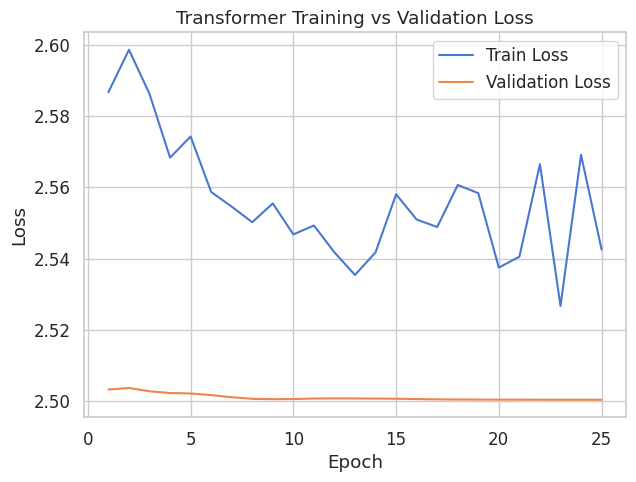

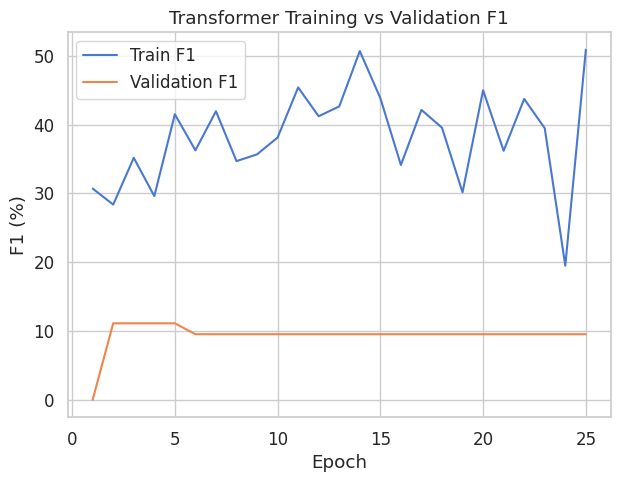

In [98]:
epochs = range(1, len(transformer_history["train_loss"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, transformer_history["train_loss"], label="Train Loss")
plt.plot(epochs, transformer_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(epochs, transformer_history["train_f1"], label="Train F1")
plt.plot(epochs, transformer_history["val_f1"], label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1 (%)")
plt.title("Transformer Training vs Validation F1")
plt.legend()
plt.grid(True)
plt.show()

In [99]:
def transformer_predict_fn(input_ids_np: np.ndarray):
    transformer_model.eval()

    with torch.no_grad():
        ids = torch.tensor(input_ids_np, dtype=torch.long).to(DEVICE)
        mask = (ids != vocab.pad_idx).float()
        sl, el = transformer_model(ids, mask)

    return sl.cpu().numpy(), el.cpu().numpy()


transformer_pipeline = QAPipeline(
    vocab=vocab,
    tokenizer=word_tok,
    model_fn=transformer_predict_fn,
    max_ctx=MAX_CTX,
    max_q=MAX_Q,
)

if len(test_df) == 0:
    raise ValueError("test_df is empty after filtering; transformer demo cannot run.")

demo_row = test_df.sample(1, random_state=123).iloc[0]
out = transformer_pipeline.predict(demo_row["question"], demo_row["context"])

print("Question :", out["question"])
print("Predicted:", out["predicted"])
print("Gold     :", demo_row["answer"])

Question : كيف تساهم خاصية التخفي في زيادة تفوق الطائرة؟
Predicted: في هروبها من الرادارات
Gold     : هروبها من الرادارات


In [100]:
# ─── Span alignment sanity check ─────────────────────────────────────────────

for i in range(10):
    row = train_df.iloc[i]

    sample = train_dataset[i]
    ids = sample["input_ids"]
    s = sample["start_idx"].item()
    e = sample["end_idx"].item()

    decoded_gold_span = " ".join(vocab.decode(ids[s:e+1].tolist()))

    print("Question:", row["question"])
    print("Dataset answer:", row["answer"])
    print("Decoded training span:", decoded_gold_span)
    print("Start / End:", s, e)
    print("-" * 80)

Question: ما اسم زوجة شاه جهان التي بُني تاج محل تخليدًا لها؟
Dataset answer: ممتاز محل
Decoded training span: ممتاز محل
Start / End: 13 14
--------------------------------------------------------------------------------
Question: ما الحدث الذي أدى إلى صعود الساموراي للسلطة؟
Dataset answer: أول حكم عسكري مركزي في تاريخ اليابان
Decoded training span: اول حكم عسكري مركزي في تاريخ اليابان
Start / End: 14 20
--------------------------------------------------------------------------------
Question: ما السلاح الأساسي للساموراي؟
Dataset answer: القوس والسهم
Decoded training span: القوس والسهم
Start / End: 9 10
--------------------------------------------------------------------------------
Question: كم استغرق بناء تاج محل؟
Dataset answer: 22 سنة
Decoded training span: 22 سنه
Start / End: 11 12
--------------------------------------------------------------------------------
Question: ما المادة الأساسية المستخدمة في بناء تاج محل؟
Dataset answer: الرخام الأبيض
Decoded training span: الرخام الابي

In [101]:
print("train_df:", len(train_df))
print("val_df  :", len(val_df))
print("test_df :", len(test_df))

train_df: 19
val_df  : 3
test_df : 7


In [102]:
target_q = "كيف تساهم خاصية التخفي في زيادة تفوق الطائرة؟"

match = df_test[df_test["question"].astype(str).str.strip() == target_q].copy()

if len(match) == 0:
    print("Question not found in df_test")
else:
    row = match.iloc[0]

    ctx_tokens = str(row["context_clean"]).split()
    s = int(row["start_idx"])
    e = int(row["end_idx"])

    print("QUESTION        :", row["question"])
    print("ANSWER RAW      :", row["answer"])
    print("ANSWER CLEAN    :", row["answer_clean"])
    print("START_IDX / END :", s, e)
    print("DECODED GOLD    :", " ".join(ctx_tokens[s:e+1]))
    print("LEFT WINDOW     :", ctx_tokens[max(0, s-4):min(len(ctx_tokens), e+5)])

QUESTION        : كيف تساهم خاصية التخفي في زيادة تفوق الطائرة؟
ANSWER RAW      : هروبها من الرادارات
ANSWER CLEAN    : هروبها من الرادارات
START_IDX / END : 3 5
DECODED GOLD    : هروبها من الرادارات
LEFT WINDOW     : ['نقطه', 'قوتها', 'في', 'هروبها', 'من', 'الرادارات', 'بالاضافه', 'لقدرتها', 'علي', 'جمع']
